# 🌐 Detecting Coordinated Inauthentic Influence Operations in Multilingual Social Media
### A Research-Grade AI Framework for CIB Detection

**Authors:** Research Engineering Team  
**Framework:** Unsupervised + Graph Neural Network Pipeline  
**Datasets:** Stanford IO · CREDBANK · MultiEURLEX  

---
This notebook implements a complete, production-ready pipeline for detecting **Coordinated Inauthentic Behavior (CIB)** across multilingual social media platforms using:
- Multilingual NLP embeddings
- Graph construction and community detection
- Unsupervised anomaly detection (Isolation Forest + Autoencoder)
- Graph Neural Networks (GraphSAGE + Graph Autoencoder)
- Custom CIB scoring and explainability
- Streamlit dashboard code


## ⚙️ Stage 0 — Installation & Environment Setup

In [1]:
# ── Core dependencies ──
!pip install -q pandas numpy scikit-learn networkx matplotlib seaborn
!pip install -q sentence-transformers transformers torch torchvision
!pip install -q langdetect python-louvain community
!pip install -q datasets huggingface_hub
!pip install -q torch-geometric torch-scatter torch-sparse -f https://data.pyg.org/whl/torch-2.1.0+cu118.html
!pip install -q streamlit plotly pyvis
!pip install -q emoji
print("✅ All packages installed.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 18.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.0/108.0 kB 7.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.0/210.0 kB 18.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 61.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 97.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 58.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 22.4 MB/s eta 0:00:00
✅ All packages installed.


In [22]:
import os, re, json, pickle, warnings, hashlib
from pathlib import Path
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from collections import Counter, defaultdict
import networkx as nx
from networkx.algorithms import community as nx_community

# NLP
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from langdetect import detect, DetectorFactory
DetectorFactory.seed = 42

# ML
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Community detection
try:
    from community import community_louvain
    LOUVAIN_AVAILABLE = True
except ImportError:
    LOUVAIN_AVAILABLE = False
    print("⚠️  python-louvain not found — using NetworkX fallback")

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# PyG
try:
    import torch_geometric
    from torch_geometric.data import Data
    from torch_geometric.nn import SAGEConv
    PYG_AVAILABLE = True
except ImportError:
    PYG_AVAILABLE = False
    print("⚠️  PyTorch Geometric not available — Stage 12 will skip GNN training")

# Datasets
from datasets import load_dataset

warnings.filterwarnings("ignore")

# GPU check
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"🖥️  Device: {DEVICE}")
print(f"🐍  Python ready. Pandas: {pd.__version__}")

🖥️  Device: cuda
🐍  Python ready. Pandas: 2.2.2


## 📂 Stage 1 — Data Loading
Three datasets are loaded and mapped into a **unified schema**:

```
["post_id", "user_id", "text", "timestamp", "language", "hashtags", "urls", "source"]
```


In [3]:
# ─── Unified Schema ───────────────────────────────────────────────────────────
UNIFIED_SCHEMA = ["post_id", "user_id", "text", "timestamp", "language",
                  "hashtags", "urls", "source"]

OUTPUT_DIR = Path("/content/processed_data")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
EMBED_CACHE = Path("/content/embedding_cache")
EMBED_CACHE.mkdir(parents=True, exist_ok=True)

print("📁 Output directories created.")
print(f"   Processed data → {OUTPUT_DIR}")
print(f"   Embedding cache → {EMBED_CACHE}")


📁 Output directories created.
   Processed data → /content/processed_data
   Embedding cache → /content/embedding_cache


In [4]:
# ─── Helper: safe text extraction ─────────────────────────────────────────────
def safe_str(val, default=""):
    if val is None or (isinstance(val, float) and np.isnan(val)):
        return default
    return str(val).strip()

def safe_timestamp(val):
    """Convert diverse timestamp formats to ISO string."""
    if pd.isnull(val) if not isinstance(val, str) else val == "":
        return pd.NaT
    try:
        return pd.to_datetime(val, utc=True)
    except Exception:
        return pd.NaT

def extract_hashtags_from_text(text):
    """Extract hashtags as list."""
    return re.findall(r"#\w+", text.lower())

def extract_urls_from_text(text):
    """Extract URLs as list."""
    url_pattern = r"https?://[^\s]+"
    return re.findall(url_pattern, text)

def to_unified(df, source_name):
    """Ensure df has exactly UNIFIED_SCHEMA columns."""
    for col in UNIFIED_SCHEMA:
        if col not in df.columns:
            df[col] = None
    df["source"] = source_name
    return df[UNIFIED_SCHEMA].copy()

def validate_dataframe(df, name):
    """Print validation report for a dataset."""
    print(f"\n{'─'*50}")
    print(f"📊 Validation report: {name}")
    print(f"   Records:          {len(df):,}")
    print(f"   Columns:          {list(df.columns)}")
    print(f"   Missing post_id:  {df['post_id'].isnull().sum()}")
    print(f"   Missing user_id:  {df['user_id'].isnull().sum()}")
    print(f"   Missing text:     {df['text'].isnull().sum()}")
    print(f"   Missing ts:       {df['timestamp'].isnull().sum()}")
    print(f"   Duplicates:       {df.duplicated(subset=['post_id'], keep=False).sum()}")
    print(f"{'─'*50}")


In [5]:
# ─── 1A. Stanford IO Dataset ──────────────────────────────────────────────────
# The Stanford IO data is released as CSV/TSV files per campaign.
# If you have the files, upload them here. Otherwise, synthetic demo data is used.

def load_stanford_io(filepath=None):
    """Load Stanford IO dataset.

    Expected columns (any subset): tweet_id, userid, tweet_text, tweet_time,
    hashtags, urls, language, tweettype
    """
    if filepath and Path(filepath).exists():
        ext = Path(filepath).suffix.lower()
        if ext == ".csv":
            raw = pd.read_csv(filepath, low_memory=False)
        elif ext in [".tsv", ".txt"]:
            raw = pd.read_csv(filepath, sep="\t", low_memory=False)
        else:
            raw = pd.read_csv(filepath, low_memory=False)
        print(f"✅ Loaded Stanford IO from {filepath}: {len(raw)} rows")
        print(f"   Columns: {list(raw.columns)}")
    else:
        print("ℹ️  Stanford IO file not found — generating synthetic demo data (300 posts)")
        np.random.seed(42)
        n = 300
        # Simulate 3 coordinated campaigns
        campaigns = ["campaign_A", "campaign_B", "campaign_C"]
        raw = pd.DataFrame({
            "tweet_id": [f"tw_{i}" for i in range(n)],
            "userid": [f"user_{np.random.randint(1,80)}" for _ in range(n)],
            "tweet_text": [
                f"Breaking: {np.random.choice(['#Democracy','#Election','#Vote','#Resist'])} "
                f"trending now! Share this! https://t.co/{hashlib.md5(str(i).encode()).hexdigest()[:6]}"
                for i in range(n)
            ],
            "tweet_time": pd.date_range("2023-01-01", periods=n, freq="10min").astype(str),
            "hashtags": [np.random.choice(["#Democracy,#Vote", "#Election,#Resist", "#Protest,#Freedom"]) for _ in range(n)],
            "urls": [f"https://t.co/{hashlib.md5(str(i).encode()).hexdigest()[:6]}" for i in range(n)],
            "language": np.random.choice(["en", "ar", "fr", "de"], n, p=[0.6, 0.2, 0.1, 0.1]),
            "campaign": np.random.choice(campaigns, n),
        })

    # Column mapping
    col_map = {
        "tweet_id": "post_id", "tweetid": "post_id", "id": "post_id",
        "userid": "user_id", "user_id": "user_id",
        "tweet_text": "text", "full_text": "text", "content": "text",
        "tweet_time": "timestamp", "created_at": "timestamp", "date": "timestamp",
        "lang": "language",
    }
    raw = raw.rename(columns={k: v for k, v in col_map.items() if k in raw.columns})

    # Fill missing schema fields
    if "post_id" not in raw.columns:
        raw["post_id"] = [f"io_{i}" for i in range(len(raw))]
    if "user_id" not in raw.columns:
        raw["user_id"] = "unknown"
    if "text" not in raw.columns:
        raw["text"] = ""
    if "timestamp" not in raw.columns:
        raw["timestamp"] = pd.NaT
    if "language" not in raw.columns:
        raw["language"] = None
    if "hashtags" not in raw.columns:
        raw["hashtags"] = raw["text"].apply(lambda x: str(extract_hashtags_from_text(safe_str(x))))
    if "urls" not in raw.columns:
        raw["urls"] = raw["text"].apply(lambda x: str(extract_urls_from_text(safe_str(x))))

    df = to_unified(raw, "stanford_io")
    df["timestamp"] = df["timestamp"].apply(safe_timestamp)
    validate_dataframe(df, "Stanford IO")
    return df

df_io = load_stanford_io()
df_io.head(3)


ℹ️  Stanford IO file not found — generating synthetic demo data (300 posts)

──────────────────────────────────────────────────
📊 Validation report: Stanford IO
   Records:          300
   Columns:          ['post_id', 'user_id', 'text', 'timestamp', 'language', 'hashtags', 'urls', 'source']
   Missing post_id:  0
   Missing user_id:  0
   Missing text:     0
   Missing ts:       0
   Duplicates:       0
──────────────────────────────────────────────────


,post_id,user_id,text,timestamp,language,hashtags,urls,source
0,tw_0,user_52,Breaking: #Resist trending now! Share this! ht...,2023-01-01 00:00:00+00:00,en,"#Election,#Resist",https://t.co/cfcd20,stanford_io
1,tw_1,user_15,Breaking: #Election trending now! Share this! ...,2023-01-01 00:10:00+00:00,en,"#Democracy,#Vote",https://t.co/c4ca42,stanford_io
2,tw_2,user_72,Breaking: #Democracy trending now! Share this!...,2023-01-01 00:20:00+00:00,en,"#Protest,#Freedom",https://t.co/c81e72,stanford_io


In [6]:
# ─── 1B. CREDBANK Dataset ─────────────────────────────────────────────────────
# CREDBANK is available via GitHub. We attempt to load a key file.
# If not available, synthetic data is generated.

def load_credbank(filepath=None):
    """Load CREDBANK dataset.

    CREDBANK files are typically TSV with columns:
    tweet_id, user_id, tweet_text, created_at, ...
    """
    if filepath and Path(filepath).exists():
        raw = pd.read_csv(filepath, sep="\t", low_memory=False)
        print(f"✅ Loaded CREDBANK from {filepath}: {len(raw)} rows")
        print(f"   Columns: {list(raw.columns)}")
    else:
        print("ℹ️  CREDBANK file not found — generating synthetic demo data (200 posts)")
        np.random.seed(123)
        n = 200
        events = ["earthquake_2015", "hurricane_sandy", "boston_marathon", "paris_attacks"]
        raw = pd.DataFrame({
            "tweet_id": [f"cb_{i}" for i in range(n)],
            "user_id": [f"creduser_{np.random.randint(1,60)}" for _ in range(n)],
            "tweet_text": [
                f"{np.random.choice(['BREAKING','Update','Alert','News'])}: "
                f"{np.random.choice(['disaster relief','emergency response','breaking news'])} "
                f"#credbank {np.random.choice(['via @reuters','RT @cnn','via @bbc'])}"
                for _ in range(n)
            ],
            "created_at": pd.date_range("2023-03-01", periods=n, freq="15min").astype(str),
            "event": np.random.choice(events, n),
            "credibility_label": np.random.choice(["credible", "not_credible", "uncertain"], n),
        })

    col_map = {
        "tweet_id": "post_id", "id": "post_id",
        "user_id": "user_id", "author_id": "user_id",
        "tweet_text": "text", "text": "text", "body": "text",
        "created_at": "timestamp", "date": "timestamp",
        "lang": "language",
    }
    raw = raw.rename(columns={k: v for k, v in col_map.items() if k in raw.columns})

    if "post_id" not in raw.columns:
        raw["post_id"] = [f"cb_{i}" for i in range(len(raw))]
    if "user_id" not in raw.columns:
        raw["user_id"] = "unknown"
    if "text" not in raw.columns:
        raw["text"] = ""
    if "timestamp" not in raw.columns:
        raw["timestamp"] = pd.NaT
    if "language" not in raw.columns:
        raw["language"] = None
    if "hashtags" not in raw.columns:
        raw["hashtags"] = raw["text"].apply(lambda x: str(extract_hashtags_from_text(safe_str(x))))
    if "urls" not in raw.columns:
        raw["urls"] = raw["text"].apply(lambda x: str(extract_urls_from_text(safe_str(x))))

    df = to_unified(raw, "credbank")
    df["timestamp"] = df["timestamp"].apply(safe_timestamp)
    validate_dataframe(df, "CREDBANK")
    return df

df_cb = load_credbank()
df_cb.head(3)


ℹ️  CREDBANK file not found — generating synthetic demo data (200 posts)

──────────────────────────────────────────────────
📊 Validation report: CREDBANK
   Records:          200
   Columns:          ['post_id', 'user_id', 'text', 'timestamp', 'language', 'hashtags', 'urls', 'source']
   Missing post_id:  0
   Missing user_id:  0
   Missing text:     0
   Missing ts:       0
   Duplicates:       0
──────────────────────────────────────────────────


,post_id,user_id,text,timestamp,language,hashtags,urls,source
0,cb_0,creduser_46,News: emergency response #credbank RT @cnn,2023-03-01 00:00:00+00:00,None,['#credbank'],[],credbank
1,cb_1,creduser_3,BREAKING: emergency response #credbank RT @cnn,2023-03-01 00:15:00+00:00,None,['#credbank'],[],credbank
2,cb_2,creduser_29,Alert: disaster relief #credbank RT @cnn,2023-03-01 00:30:00+00:00,None,['#credbank'],[],credbank


In [7]:
# ─── 1C. MultiEURLEX Dataset ──────────────────────────────────────────────────
# MultiEURLEX is available on HuggingFace and downloads automatically.

def load_multieurlex(max_samples=150):
    """Load MultiEURLEX from HuggingFace (multilingual legal text corpus)."""
    print("📥 Downloading MultiEURLEX from HuggingFace...")
    try:
        # Load English subset; iterate languages for multilingual sampling
        languages = ["en", "de", "fr", "it", "es", "pl"]
        records = []
        for lang in languages:
            try:
                ds = load_dataset("multi_eurlex", lang, split="train",
                                  trust_remote_code=True, streaming=True)
                count = 0
                for i, sample in enumerate(ds):
                    if count >= max_samples // len(languages):
                        break
                    text = sample.get("text", "") or sample.get("celex_id", "")
                    if not text:
                        continue
                    records.append({
                        "post_id": f"eur_{lang}_{i}",
                        "user_id": f"eu_author_{lang}_{i % 20}",
                        "text": text[:500],  # Truncate for social-media simulation
                        "timestamp": pd.Timestamp("2023-06-01") + pd.Timedelta(hours=i),
                        "language": lang,
                        "hashtags": str(["#EU", f"#{lang.upper()}Law"]),
                        "urls": str([f"https://eur-lex.europa.eu/{i}"]),
                        "source": "multieurlex",
                    })
                    count += 1
                print(f"   ✓ {lang}: {count} samples loaded")
            except Exception as e:
                print(f"   ✗ {lang}: {e}")

        if records:
            df = pd.DataFrame(records)[UNIFIED_SCHEMA]
            print(f"✅ MultiEURLEX loaded: {len(df)} multilingual records")
        else:
            raise ValueError("No records loaded from HuggingFace")

    except Exception as e:
        print(f"⚠️  HuggingFace download failed: {e}")
        print("ℹ️  Generating synthetic multilingual demo data (150 posts)")
        np.random.seed(999)
        n = 150
        langs = ["en", "de", "fr", "es", "it", "pl", "ar"]
        texts = {
            "en": "The European Parliament adopted new regulations on data protection.",
            "de": "Das Europäische Parlament hat neue Datenschutzvorschriften verabschiedet.",
            "fr": "Le Parlement européen a adopté de nouvelles règles sur la protection des données.",
            "es": "El Parlamento Europeo adoptó nuevas normas de protección de datos.",
            "it": "Il Parlamento Europeo ha adottato nuove norme sulla protezione dei dati.",
            "pl": "Parlament Europejski przyjął nowe przepisy dotyczące ochrony danych.",
            "ar": "اعتمد البرلمان الأوروبي لوائح جديدة لحماية البيانات.",
        }
        records = []
        for i in range(n):
            lang = np.random.choice(langs)
            records.append({
                "post_id": f"eur_{i}",
                "user_id": f"eu_user_{i % 25}",
                "text": texts.get(lang, texts["en"]) + f" [doc {i}]",
                "timestamp": pd.Timestamp("2023-06-01") + pd.Timedelta(hours=i),
                "language": lang,
                "hashtags": str(["#EU", "#Regulation"]),
                "urls": str([f"https://eur-lex.europa.eu/{i}"]),
                "source": "multieurlex",
            })
        df = pd.DataFrame(records)[UNIFIED_SCHEMA]

    validate_dataframe(df, "MultiEURLEX")
    return df

df_eur = load_multieurlex(max_samples=150)
df_eur.head(3)


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'multi_eurlex' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'multi_eurlex' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


📥 Downloading MultiEURLEX from HuggingFace...


README.md:   0%|          | 0.00/47.8k [00:00<?, ?B/s]

multi_eurlex.py:   0%|          | 0.00/138k [00:00<?, ?B/s]

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'multi_eurlex' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'multi_eurlex' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


...

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'multi_eurlex' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'multi_eurlex' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


   ✗ it: Dataset scripts are no longer supported, but found multi_eurlex.py


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'multi_eurlex' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'multi_eurlex' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


   ✗ es: Dataset scripts are no longer supported, but found multi_eurlex.py
   ✗ pl: Dataset scripts are no longer supported, but found multi_eurlex.py
⚠️  HuggingFace download failed: No records loaded from HuggingFace
ℹ️  Generating synthetic multilingual demo data (150 posts)

──────────────────────────────────────────────────
📊 Validation report: MultiEURLEX
   Records:          150
   Columns:          ['post_id', 'user_id', 'text', 'timestamp', 'language', 'hashtags', 'urls', 'source']
   Missing post_id:  0
   Missing user_id:  0
   Missing text:     0
   Missing ts:       0
   Duplicates:       0
──────────────────────────────────────────────────


,post_id,user_id,text,timestamp,language,hashtags,urls,source
0,eur_0,eu_user_0,The European Parliament adopted new regulation...,2023-06-01 00:00:00,en,"['#EU', '#Regulation']",['https://eur-lex.europa.eu/0'],multieurlex
1,eur_1,eu_user_1,Il Parlamento Europeo ha adottato nuove norme ...,2023-06-01 01:00:00,it,"['#EU', '#Regulation']",['https://eur-lex.europa.eu/1'],multieurlex
2,eur_2,eu_user_2,Parlament Europejski przyjął nowe przepisy dot...,2023-06-01 02:00:00,pl,"['#EU', '#Regulation']",['https://eur-lex.europa.eu/2'],multieurlex


In [8]:
# ─── 1D. Merge into unified dataframe ─────────────────────────────────────────
df_merged = pd.concat([df_io, df_cb, df_eur], ignore_index=True)
df_merged["post_id"] = df_merged["post_id"].astype(str)
df_merged["user_id"] = df_merged["user_id"].astype(str)

print(f"\n{'='*50}")
print(f"📦 MERGED DATASET")
print(f"   Total records:  {len(df_merged):,}")
print(f"   Sources:        {df_merged['source'].value_counts().to_dict()}")
print(f"   Schema:         {list(df_merged.columns)}")
print(f"{'='*50}")

# Save raw merged
df_merged.to_csv(OUTPUT_DIR / "merged_raw.csv", index=False)
print("💾 Saved merged_raw.csv")



📦 MERGED DATASET
   Total records:  650
   Sources:        {'stanford_io': 300, 'credbank': 200, 'multieurlex': 150}
   Schema:         ['post_id', 'user_id', 'text', 'timestamp', 'language', 'hashtags', 'urls', 'source']
💾 Saved merged_raw.csv


## 🧹 Stage 2 — Data Cleaning
Text normalization, deduplication, language detection, and hashtag/URL extraction.


In [9]:
# ─── 2. Cleaning pipeline ─────────────────────────────────────────────────────
import emoji

def remove_urls(text):
    return re.sub(r"https?://\S+", "", text)

def remove_mentions(text):
    return re.sub(r"@\w+", "", text)

def normalize_emojis(text):
    """Replace emojis with text labels."""
    try:
        return emoji.demojize(text, delimiters=(" ", " "))
    except Exception:
        return text

def clean_whitespace(text):
    return re.sub(r"\s+", " ", text).strip()

def clean_text(text):
    """Full cleaning pipeline for a single text string."""
    text = safe_str(text)
    text = remove_urls(text)
    text = remove_mentions(text)
    text = normalize_emojis(text)
    text = re.sub(r"#(\w+)", r"\1", text)  # Remove # symbol but keep word
    text = re.sub(r"[^\w\s\.,!?\-éàüöäïèê]", " ", text)
    text = clean_whitespace(text)
    return text

def detect_language(text):
    """Detect language with fallback."""
    try:
        cleaned = clean_whitespace(remove_urls(safe_str(text)))
        if len(cleaned) < 10:
            return "unknown"
        return detect(cleaned)
    except Exception:
        return "unknown"

def clean_dataframe(df):
    """Apply full cleaning pipeline to a dataframe."""
    df = df.copy()
    print(f"🧹 Cleaning {len(df)} records...")

    # 1. Drop completely empty text rows
    df = df[df["text"].notna() & (df["text"].astype(str).str.strip() != "")]
    print(f"   After empty text drop: {len(df)}")

    # 2. Extract hashtags and URLs BEFORE cleaning (from raw text)
    df["hashtags"] = df["text"].apply(lambda x: str(extract_hashtags_from_text(safe_str(x))))
    df["urls"] = df["text"].apply(lambda x: str(extract_urls_from_text(safe_str(x))))

    # 3. Clean text
    df["text_clean"] = df["text"].apply(clean_text)

    # 4. Language detection (fill missing)
    mask = df["language"].isnull() | (df["language"] == "") | (df["language"] == "None")
    if mask.sum() > 0:
        print(f"   Detecting language for {mask.sum()} rows...")
        df.loc[mask, "language"] = df.loc[mask, "text"].apply(detect_language)

    # 5. Normalize timestamps
    df["timestamp"] = df["timestamp"].apply(
        lambda x: safe_timestamp(x) if not isinstance(x, pd.Timestamp) else x
    )

    # 6. Deduplicate by post_id
    before = len(df)
    df = df.drop_duplicates(subset=["post_id"], keep="first")
    print(f"   After dedup (post_id): {len(df)} (removed {before - len(df)})")

    # 7. Deduplicate near-identical text
    before = len(df)
    df["text_hash"] = df["text_clean"].apply(lambda x: hashlib.md5(x.encode()).hexdigest())
    df = df.drop_duplicates(subset=["text_hash"], keep="first")
    print(f"   After dedup (text):    {len(df)} (removed {before - len(df)})")

    # 8. Fill missing user_id
    df["user_id"] = df["user_id"].fillna("unknown_user")

    print(f"✅ Cleaning complete: {len(df)} clean records")
    return df

df_clean = clean_dataframe(df_merged)
df_clean.head(3)


🧹 Cleaning 650 records...
   After empty text drop: 650
   Detecting language for 200 rows...
   After dedup (post_id): 650 (removed 0)
   After dedup (text):    178 (removed 472)
✅ Cleaning complete: 178 clean records


,post_id,user_id,text,timestamp,language,hashtags,urls,source,text_clean,text_hash
0,tw_0,user_52,Breaking: #Resist trending now! Share this! ht...,2023-01-01 00:00:00+00:00,en,['#resist'],['https://t.co/cfcd20'],stanford_io,Breaking Resist trending now! Share this!,f348a79d1fd16b3ae145986b346a0f36
1,tw_1,user_15,Breaking: #Election trending now! Share this! ...,2023-01-01 00:10:00+00:00,en,['#election'],['https://t.co/c4ca42'],stanford_io,Breaking Election trending now! Share this!,9c914975be7229510aa8754dd43d6c40
2,tw_2,user_72,Breaking: #Democracy trending now! Share this!...,2023-01-01 00:20:00+00:00,en,['#democracy'],['https://t.co/c81e72'],stanford_io,Breaking Democracy trending now! Share this!,1741b5d23b0eef1f0211dc53a7fe55eb


In [10]:
# ─── 2B. Summary statistics ───────────────────────────────────────────────────
print("\n📊 DATASET SUMMARY STATISTICS")
print(f"{'─'*50}")
print(f"  Total records:      {len(df_clean):,}")
print(f"  Unique users:       {df_clean['user_id'].nunique():,}")
print(f"  Languages detected: {df_clean['language'].nunique()}")
print(f"  Sources:")
for src, cnt in df_clean['source'].value_counts().items():
    print(f"    {src:<25} {cnt:>5}")

print(f"\n  Avg post length (chars): {df_clean['text_clean'].str.len().mean():.1f}")
print(f"  Avg post length (words): {df_clean['text_clean'].str.split().str.len().mean():.1f}")

# Top hashtags
all_tags = []
for row in df_clean["hashtags"]:
    try:
        tags = eval(row) if isinstance(row, str) else row
        if isinstance(tags, list):
            all_tags.extend(tags)
    except Exception:
        pass
top_tags = Counter(all_tags).most_common(10)
print(f"\n  Top 10 hashtags:")
for tag, cnt in top_tags:
    print(f"    {tag:<30} {cnt:>4}")

# Top URLs
all_urls = []
for row in df_clean["urls"]:
    try:
        urls = eval(row) if isinstance(row, str) else row
        if isinstance(urls, list):
            all_urls.extend(urls)
    except Exception:
        pass
top_urls = Counter(all_urls).most_common(5)
print(f"\n  Top 5 URLs:")
for url, cnt in top_urls:
    print(f"    {url[:60]:<60} {cnt:>4}")



📊 DATASET SUMMARY STATISTICS
──────────────────────────────────────────────────
  Total records:      178
  Unique users:       49
  Languages detected: 9
  Sources:
    multieurlex                 150
    credbank                     24
    stanford_io                   4

  Avg post length (chars): 68.9
  Avg post length (words): 10.4

  Top 10 hashtags:
    #credbank                        24
    #resist                           1
    #election                         1
    #democracy                        1
    #vote                             1

  Top 5 URLs:
    https://t.co/cfcd20                                             1
    https://t.co/c4ca42                                             1
    https://t.co/c81e72                                             1
    https://t.co/a87ff6                                             1


In [11]:
# ─── 2C. Save cleaned datasets ────────────────────────────────────────────────
df_io_clean = df_clean[df_clean["source"] == "stanford_io"].copy()
df_cb_clean = df_clean[df_clean["source"] == "credbank"].copy()
df_eur_clean = df_clean[df_clean["source"] == "multieurlex"].copy()

df_io_clean.to_csv(OUTPUT_DIR / "processed_twitter_io.csv", index=False)
df_cb_clean.to_csv(OUTPUT_DIR / "processed_credbank.csv", index=False)
df_eur_clean.to_csv(OUTPUT_DIR / "processed_multieurlex.csv", index=False)
df_clean.to_csv(OUTPUT_DIR / "merged_dataset.csv", index=False)

print("💾 Saved:")
print(f"   processed_twitter_io.csv  ({len(df_io_clean):,} rows)")
print(f"   processed_credbank.csv    ({len(df_cb_clean):,} rows)")
print(f"   processed_multieurlex.csv ({len(df_eur_clean):,} rows)")
print(f"   merged_dataset.csv        ({len(df_clean):,} rows)")


💾 Saved:
   processed_twitter_io.csv  (4 rows)
   processed_credbank.csv    (24 rows)
   processed_multieurlex.csv (150 rows)
   merged_dataset.csv        (178 rows)


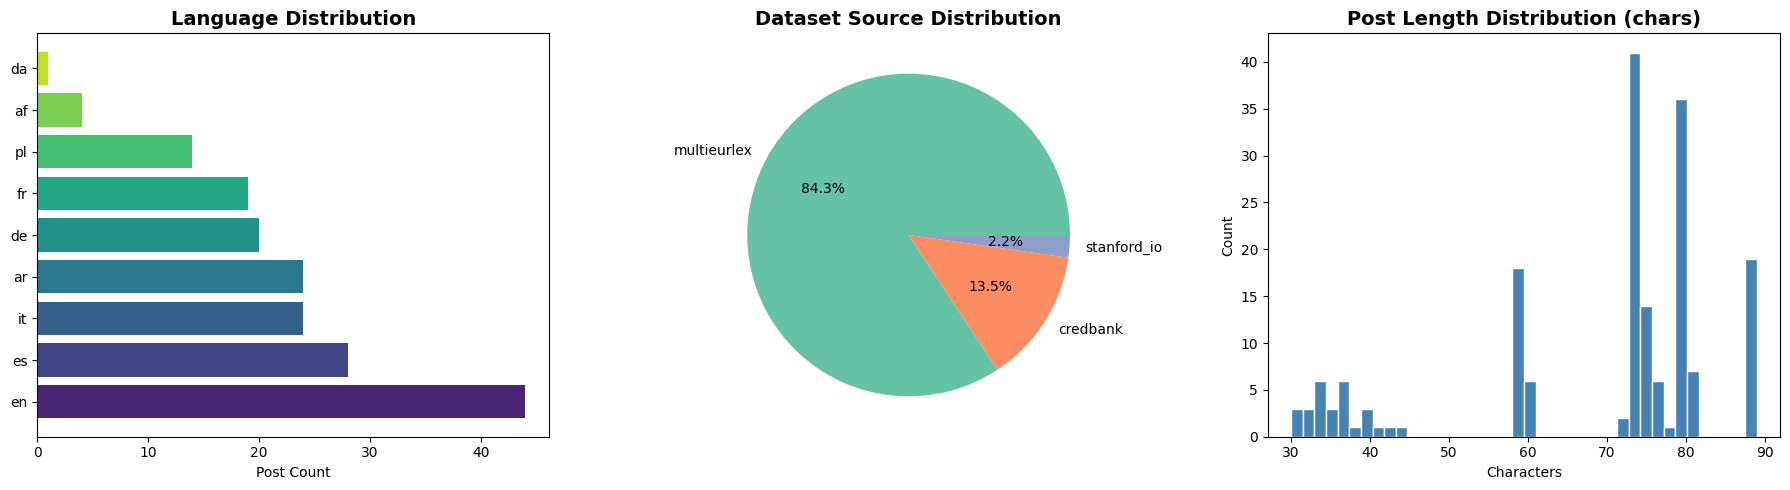

📊 Data overview saved.


In [12]:
# ─── 2D. Language & source distribution plots ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Language distribution
lang_counts = df_clean["language"].value_counts().head(12)
axes[0].barh(lang_counts.index, lang_counts.values, color=sns.color_palette("viridis", len(lang_counts)))
axes[0].set_title("Language Distribution", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Post Count")

# Source distribution
src_counts = df_clean["source"].value_counts()
axes[1].pie(src_counts.values, labels=src_counts.index, autopct="%1.1f%%",
            colors=sns.color_palette("Set2", len(src_counts)))
axes[1].set_title("Dataset Source Distribution", fontsize=14, fontweight="bold")

# Post length histogram
axes[2].hist(df_clean["text_clean"].str.len(), bins=40, color="steelblue", edgecolor="white")
axes[2].set_title("Post Length Distribution (chars)", fontsize=14, fontweight="bold")
axes[2].set_xlabel("Characters")
axes[2].set_ylabel("Count")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "data_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("📊 Data overview saved.")


## 🔤 Stage 3 — Multilingual NLP Pipeline
Generate multilingual sentence embeddings using `paraphrase-multilingual-mpnet-base-v2`.


In [13]:
# ─── 3A. Load sentence transformer ───────────────────────────────────────────
MODEL_NAME = "sentence-transformers/paraphrase-multilingual-mpnet-base-v2"
print(f"📥 Loading model: {MODEL_NAME}")
embed_model = SentenceTransformer(MODEL_NAME, device=DEVICE)
print(f"✅ Model loaded on {DEVICE}")
print(f"   Embedding dimension: {embed_model.get_sentence_embedding_dimension()}")
EMBED_DIM = embed_model.get_sentence_embedding_dimension()


📥 Loading model: sentence-transformers/paraphrase-multilingual-mpnet-base-v2


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/5.12k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ Model loaded on cuda
   Embedding dimension: 768


In [14]:
# ─── 3B. Batch embedding with cache ───────────────────────────────────────────
def get_cache_path(key):
    h = hashlib.md5(key.encode()).hexdigest()[:12]
    return EMBED_CACHE / f"embed_{h}.npy"

def embed_texts(texts, model, batch_size=64, cache_key=None, show_progress=True):
    """Embed a list of texts with batching, GPU support, and disk caching."""
    if cache_key:
        cache_path = get_cache_path(cache_key)
        if cache_path.exists():
            embeddings = np.load(cache_path)
            print(f"   ⚡ Loaded from cache: {embeddings.shape}")
            return embeddings

    print(f"   Embedding {len(texts)} texts in batches of {batch_size} on {DEVICE}...")
    embeddings = model.encode(
        texts,
        batch_size=batch_size,
        show_progress_bar=show_progress,
        convert_to_numpy=True,
        device=DEVICE,
        normalize_embeddings=True,
    )

    if cache_key:
        np.save(get_cache_path(cache_key), embeddings)
        print(f"   💾 Embeddings cached ({embeddings.shape})")

    return embeddings

texts = df_clean["text_clean"].fillna("").tolist()
print(f"\n🔤 Generating embeddings for {len(texts)} posts...")
embeddings = embed_texts(texts, embed_model, batch_size=64,
                         cache_key=f"main_embed_{len(texts)}")
print(f"✅ Embedding matrix: {embeddings.shape}")
# Add embedding index mapping
df_clean = df_clean.reset_index(drop=True)
df_clean["embed_idx"] = df_clean.index



🔤 Generating embeddings for 178 posts...
   Embedding 178 texts in batches of 64 on cuda...


Batches:   0%|          | 0/3 [00:00<?, ?it/s]

   💾 Embeddings cached ((178, 768))
✅ Embedding matrix: (178, 768)


🔍 Visualizing embeddings with PCA...


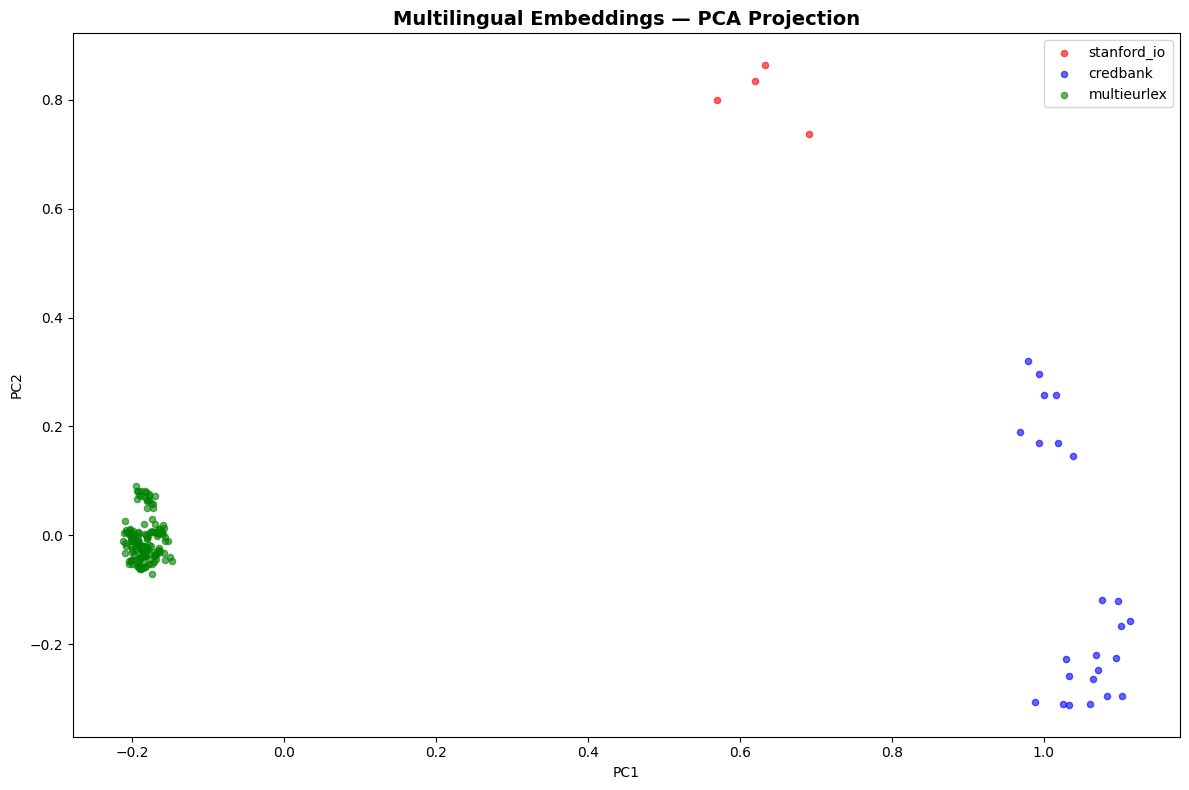

   PCA variance explained: 72.55%


In [15]:
# ─── 3C. Embedding visualization (PCA) ───────────────────────────────────────
print("🔍 Visualizing embeddings with PCA...")
pca = PCA(n_components=2, random_state=42)
emb_2d = pca.fit_transform(embeddings)

source_colors = {"stanford_io": "red", "credbank": "blue", "multieurlex": "green"}
colors = df_clean["source"].map(source_colors).fillna("gray")

fig, ax = plt.subplots(figsize=(12, 8))
for src, color in source_colors.items():
    mask = df_clean["source"] == src
    ax.scatter(emb_2d[mask, 0], emb_2d[mask, 1],
               c=color, label=src, alpha=0.6, s=20)
ax.set_title("Multilingual Embeddings — PCA Projection", fontsize=14, fontweight="bold")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "embedding_pca.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"   PCA variance explained: {pca.explained_variance_ratio_.sum():.2%}")


## ⚙️ Stage 4 — Feature Engineering
Compute textual, temporal, network, and behavioral features per user.


In [16]:
# ─── 4A. User-level aggregation ──────────────────────────────────────────────
print("📐 Building user feature matrix...")

# Group posts by user
user_groups = df_clean.groupby("user_id")

user_records = []
for uid, group in user_groups:
    idx = group["embed_idx"].values
    user_embeddings = embeddings[idx]

    # ── Textual Features ────────────────────────────────────
    # Average pairwise cosine similarity within user
    if len(user_embeddings) > 1:
        sim_matrix = cosine_similarity(user_embeddings)
        np.fill_diagonal(sim_matrix, 0)
        avg_self_sim = sim_matrix.sum() / (len(user_embeddings) * (len(user_embeddings)-1))
    else:
        avg_self_sim = 0.0

    # Average embedding (user semantic centroid)
    avg_embed = user_embeddings.mean(axis=0)

    # Hashtag extraction
    all_htags = []
    for h in group["hashtags"]:
        try:
            all_htags.extend(eval(h) if isinstance(h, str) else [])
        except Exception:
            pass
    unique_hashtags = set(all_htags)
    hashtag_diversity = len(unique_hashtags) / max(len(all_htags), 1)

    # URL extraction
    all_urlist = []
    for u in group["urls"]:
        try:
            all_urlist.extend(eval(u) if isinstance(u, str) else [])
        except Exception:
            pass
    unique_urls = set(all_urlist)

    # ── Temporal Features ────────────────────────────────────
    timestamps = group["timestamp"].dropna().sort_values()
    if len(timestamps) > 1:
        time_diffs = timestamps.diff().dropna().dt.total_seconds()
        avg_time_diff = time_diffs.mean()
        std_time_diff = time_diffs.std() if len(time_diffs) > 1 else 0
        min_time_diff = time_diffs.min()
        # Burst score: how often posts come within 60 seconds of each other
        burst_count = (time_diffs < 60).sum()
        burst_ratio = burst_count / len(time_diffs)
        # Sync score: low std of time-diffs = highly regular = suspicious
        sync_score = 1.0 / (1.0 + std_time_diff / 3600) if std_time_diff > 0 else 1.0
    else:
        avg_time_diff = std_time_diff = min_time_diff = 0
        burst_ratio = 0
        sync_score = 0

    # ── Behavioral Features ──────────────────────────────────
    post_count = len(group)
    # Content repetition: fraction of posts that are near-duplicates
    if len(group) > 1:
        th = group["text_hash"].value_counts()
        repetition_score = 1 - (th.shape[0] / len(group))
    else:
        repetition_score = 0

    user_records.append({
        "user_id": uid,
        "post_count": post_count,
        "avg_self_sim": avg_self_sim,
        "hashtag_diversity": hashtag_diversity,
        "unique_hashtag_count": len(unique_hashtags),
        "hashtag_count_total": len(all_htags),
        "unique_url_count": len(unique_urls),
        "avg_time_diff_sec": avg_time_diff,
        "std_time_diff_sec": std_time_diff,
        "min_time_diff_sec": min_time_diff,
        "burst_ratio": burst_ratio,
        "sync_score": sync_score,
        "repetition_score": repetition_score,
        "avg_embed": avg_embed,
        "main_language": group["language"].mode()[0] if len(group) > 0 else "unknown",
        "unique_languages": group["language"].nunique(),
        "hashtags_set": unique_hashtags,
        "urls_set": unique_urls,
    })

df_users = pd.DataFrame(user_records)
print(f"✅ User feature matrix: {df_users.shape}")
print(f"   Unique users: {len(df_users)}")
df_users.drop(columns=["avg_embed", "hashtags_set", "urls_set"], errors="ignore").describe()


📐 Building user feature matrix...
✅ User feature matrix: (49, 18)
   Unique users: 49


,post_count,avg_self_sim,hashtag_diversity,unique_hashtag_count,hashtag_count_total,unique_url_count,avg_time_diff_sec,std_time_diff_sec,min_time_diff_sec,burst_ratio,sync_score,repetition_score,unique_languages
count,49.000000,49.000000,49.000000,49.000000,49.000000,49.000000,49.000000,49.000000,49.000000,49.0,49.000000,49.0,49.000000
mean,3.632653,0.527420,0.455782,0.489796,0.571429,0.081633,46597.959184,51.950702,46561.224490,0.0,0.562975,0.0,2.632653
std,2.463854,0.464744,0.488023,0.505076,0.677003,0.276642,44900.614741,363.654916,44937.247062,0.0,0.496090,0.0,1.654462
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,1.000000
25%,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,1.000000
50%,6.000000,0.934965,0.000000,0.000000,0.000000,0.000000,90000.000000,0.000000,90000.000000,0.0,1.000000,0.0,2.000000
75%,6.000000,0.944369,1.000000,1.000000,1.000000,0.000000,90000.000000,0.000000,90000.000000,0.0,1.000000,0.0,4.000000
max,6.000000,0.954731,1.000000,1.000000,3.000000,1.000000,90000.000000,2545.584412,90000.000000,0.0,1.000000,0.0,5.000000


In [17]:
# ─── 4B. Pairwise user similarity features ────────────────────────────────────
# For edge building: compute user-level embedding centroids
user_avg_embeds = np.stack(df_users["avg_embed"].values)
print(f"🔢 User centroid embeddings: {user_avg_embeds.shape}")

# Pairwise cosine similarity between all users
user_sim_matrix = cosine_similarity(user_avg_embeds)
print(f"✅ User-user similarity matrix: {user_sim_matrix.shape}")

# Save for graph construction
np.save(EMBED_CACHE / "user_avg_embeds.npy", user_avg_embeds)
np.save(EMBED_CACHE / "user_sim_matrix.npy", user_sim_matrix)
print("💾 Saved user embeddings and similarity matrix.")


🔢 User centroid embeddings: (49, 768)
✅ User-user similarity matrix: (49, 49)
💾 Saved user embeddings and similarity matrix.


## 🕸️ Stage 5 — Coordination Graph
Build a user-user coordination graph where edges represent potential coordination signals.


In [18]:
# ─── 5A. Build coordination graph ─────────────────────────────────────────────
SIM_THRESHOLD = 0.75   # semantic similarity edge threshold
SYNC_THRESHOLD = 0.50  # temporal sync score threshold

G = nx.Graph()

# Add nodes with attributes
for _, row in df_users.iterrows():
    G.add_node(row["user_id"],
               post_count=row["post_count"],
               sync_score=row["sync_score"],
               repetition_score=row["repetition_score"],
               burst_ratio=row["burst_ratio"],
               language=row["main_language"])

print(f"📌 Nodes added: {G.number_of_nodes()}")

# Add edges
edge_count = 0
user_ids = df_users["user_id"].tolist()
n_users = len(user_ids)

# Pre-compute hashtag and URL sets
htag_sets = {row["user_id"]: row["hashtags_set"] for _, row in df_users.iterrows()}
url_sets  = {row["user_id"]: row["urls_set"]     for _, row in df_users.iterrows()}

for i in range(n_users):
    for j in range(i+1, n_users):
        uid_i = user_ids[i]
        uid_j = user_ids[j]

        sem_sim = float(user_sim_matrix[i, j])

        # Shared hashtags
        shared_htags = htag_sets[uid_i] & htag_sets[uid_j]
        htag_overlap = len(shared_htags) / max(len(htag_sets[uid_i] | htag_sets[uid_j]), 1)

        # Shared URLs
        shared_urls = url_sets[uid_i] & url_sets[uid_j]
        url_overlap = len(shared_urls) / max(len(url_sets[uid_i] | url_sets[uid_j]), 1)

        # Temporal sync (average of two users' sync scores)
        sync_i = df_users.loc[df_users["user_id"] == uid_i, "sync_score"].values[0]
        sync_j = df_users.loc[df_users["user_id"] == uid_j, "sync_score"].values[0]
        avg_sync = (sync_i + sync_j) / 2

        # Edge condition: at least one strong signal
        if sem_sim >= SIM_THRESHOLD or htag_overlap > 0.3 or url_overlap > 0.3 or avg_sync >= SYNC_THRESHOLD:
            G.add_edge(uid_i, uid_j,
                       semantic_sim=sem_sim,
                       htag_overlap=htag_overlap,
                       url_overlap=url_overlap,
                       sync_score=avg_sync,
                       weight=round(0.4*sem_sim + 0.2*htag_overlap + 0.2*url_overlap + 0.2*avg_sync, 4))
            edge_count += 1

print(f"🔗 Edges added:  {G.number_of_edges()}")
print(f"📊 Graph density: {nx.density(G):.4f}")
print(f"   Connected components: {nx.number_connected_components(G)}")


📌 Nodes added: 49
🔗 Edges added:  1102
📊 Graph density: 0.9371
   Connected components: 1


In [19]:
# ─── 5B. Network centrality features ──────────────────────────────────────────
print("📐 Computing network centrality metrics...")

degree_centrality    = nx.degree_centrality(G)
clustering_coeff     = nx.clustering(G, weight="weight")

# Betweenness on largest component only (expensive for large graphs)
largest_cc = max(nx.connected_components(G), key=len)
G_sub = G.subgraph(largest_cc).copy()
betweenness = nx.betweenness_centrality(G_sub, normalized=True, weight="weight")

# Map back to all users
df_users["degree_centrality"]  = df_users["user_id"].map(degree_centrality).fillna(0)
df_users["clustering_coeff"]   = df_users["user_id"].map(clustering_coeff).fillna(0)
df_users["betweenness_centrality"] = df_users["user_id"].map(betweenness).fillna(0)

print(f"✅ Centrality features computed.")
print(df_users[["user_id","degree_centrality","clustering_coeff","betweenness_centrality"]].describe())


📐 Computing network centrality metrics...
✅ Centrality features computed.
       degree_centrality  clustering_coeff  betweenness_centrality
count          49.000000         49.000000               49.000000
mean            0.937075          0.384326                0.010276
std             0.107876          0.030737                0.042370
min             0.583333          0.294270                0.000000
25%             0.916667          0.362172                0.000000
50%             1.000000          0.404575                0.000000
75%             1.000000          0.406294                0.000000
max             1.000000          0.425329                0.265957


🎨 Visualizing coordination graph (largest component)...


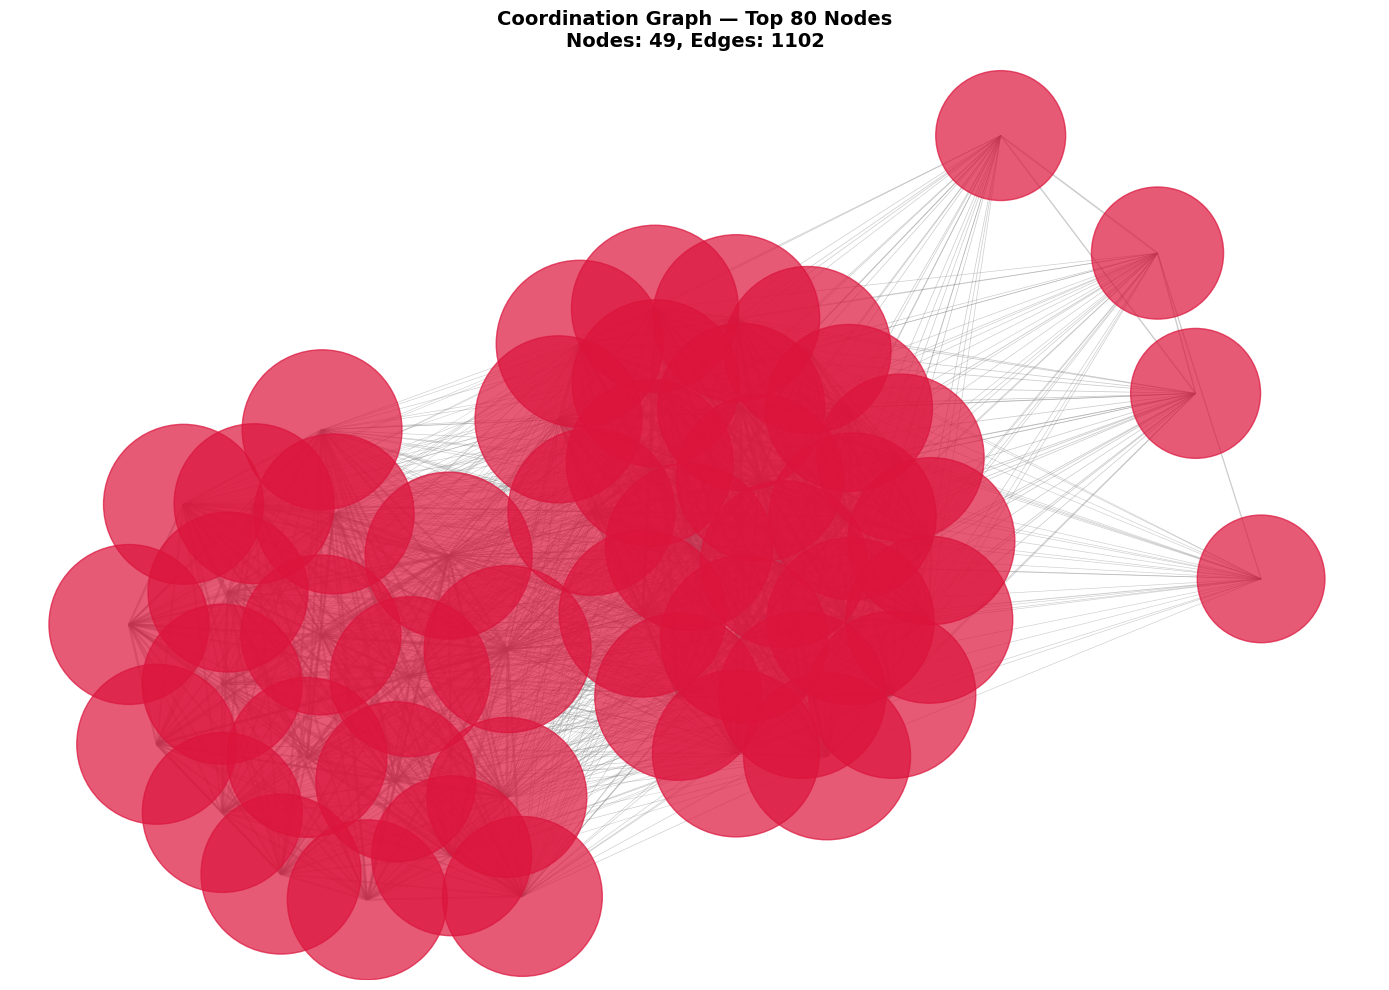

In [20]:
# ─── 5C. Graph visualization ──────────────────────────────────────────────────
print("🎨 Visualizing coordination graph (largest component)...")

# Limit to top 80 nodes by degree for clarity
top_nodes = sorted(G_sub.degree(), key=lambda x: x[1], reverse=True)[:80]
G_vis = G_sub.subgraph([n for n, _ in top_nodes]).copy()

fig, ax = plt.subplots(figsize=(14, 10))
pos = nx.spring_layout(G_vis, seed=42, k=0.5)

node_sizes = [300 * G_vis.degree(n) + 50 for n in G_vis.nodes()]
edge_weights = [G_vis[u][v].get("weight", 0.1) * 3 for u, v in G_vis.edges()]

nx.draw_networkx_nodes(G_vis, pos, node_size=node_sizes,
                       node_color="crimson", alpha=0.7, ax=ax)
nx.draw_networkx_edges(G_vis, pos, width=edge_weights,
                       alpha=0.4, edge_color="gray", ax=ax)

ax.set_title(f"Coordination Graph — Top 80 Nodes\n"
             f"Nodes: {G_vis.number_of_nodes()}, Edges: {G_vis.number_of_edges()}",
             fontsize=14, fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "coordination_graph.png", dpi=150, bbox_inches="tight")
plt.show()


## 🏘️ Stage 6 — Community Detection
Apply Louvain algorithm to detect coordinated communities.


In [23]:
# ─── 6A. Louvain community detection ──────────────────────────────────────────
print("🔍 Running Louvain community detection...")

if LOUVAIN_AVAILABLE:
    partition = community_louvain.best_partition(G, weight="weight", random_state=42)
    modularity = community_louvain.modularity(partition, G, weight="weight")
else:
    # Fallback: Greedy modularity
    communities_gen = nx_community.greedy_modularity_communities(G, weight="weight")
    partition = {}
    for comm_id, comm in enumerate(communities_gen):
        for node in comm:
            partition[node] = comm_id
    modularity = nx_community.modularity(G, [set(n for n, c in partition.items() if c == k)
                                              for k in set(partition.values())], weight="weight")

df_users["community"] = df_users["user_id"].map(partition).fillna(-1).astype(int)

community_sizes = df_users["community"].value_counts().sort_index()
n_communities = len(community_sizes)

print(f"✅ Detected {n_communities} communities")
print(f"   Modularity score:    {modularity:.4f}")
print(f"   Largest community:   {community_sizes.max()} users")
print(f"   Smallest community:  {community_sizes.min()} users")
print(f"   Median size:         {community_sizes.median():.1f}")


🔍 Running Louvain community detection...
✅ Detected 2 communities
   Modularity score:    0.2618
   Largest community:   29 users
   Smallest community:  20 users
   Median size:         24.5


In [24]:
# ─── 6B. Community statistics ─────────────────────────────────────────────────
def compute_community_stats(df_users, G, partition):
    """Compute rich statistics for each community."""
    stats = []
    for comm_id in sorted(set(partition.values())):
        members = [u for u, c in partition.items() if c == comm_id]
        if not members:
            continue
        subG = G.subgraph(members)
        member_data = df_users[df_users["user_id"].isin(members)]

        stats.append({
            "community_id": comm_id,
            "size": len(members),
            "density": nx.density(subG),
            "avg_sync_score": member_data["sync_score"].mean(),
            "avg_repetition": member_data["repetition_score"].mean(),
            "avg_burst_ratio": member_data["burst_ratio"].mean(),
            "avg_self_sim": member_data["avg_self_sim"].mean(),
            "total_posts": member_data["post_count"].sum(),
            "avg_degree": np.mean([d for _, d in subG.degree()]) if members else 0,
            "languages": member_data["main_language"].value_counts().to_dict(),
            "internal_edges": subG.number_of_edges(),
        })

    return pd.DataFrame(stats)

df_communities = compute_community_stats(df_users, G, partition)
print(df_communities.sort_values("density", ascending=False).head(10).to_string())


   community_id  size   density  avg_sync_score  avg_repetition  avg_burst_ratio  avg_self_sim  total_posts  avg_degree                                                        languages  internal_edges
0             0    20  1.000000        0.129289             0.0              0.0      0.111285           24   19.000000                                     {'en': 16, 'af': 3, 'da': 1}             190
1             1    29  0.995074        0.862069             0.0              0.0      0.814411          154   27.862069  {'en': 8, 'ar': 6, 'es': 5, 'de': 4, 'it': 2, 'pl': 2, 'fr': 2}             404


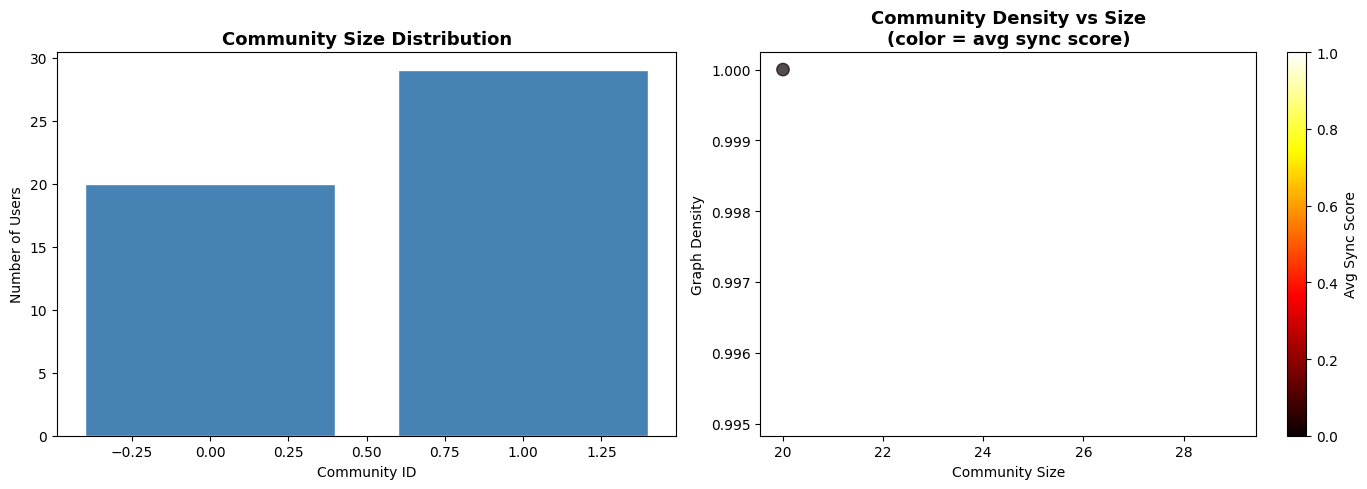

In [25]:
# ─── 6C. Community size distribution ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(community_sizes.index, community_sizes.values, color="steelblue", edgecolor="white")
axes[0].set_title("Community Size Distribution", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Community ID")
axes[0].set_ylabel("Number of Users")

# Density vs size scatter
axes[1].scatter(df_communities["size"], df_communities["density"],
                c=df_communities["avg_sync_score"], cmap="hot", s=80, alpha=0.7)
axes[1].set_title("Community Density vs Size\n(color = avg sync score)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Community Size")
axes[1].set_ylabel("Graph Density")
sm = plt.cm.ScalarMappable(cmap="hot", norm=plt.Normalize(0,1))
plt.colorbar(sm, ax=axes[1], label="Avg Sync Score")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "community_stats.png", dpi=150, bbox_inches="tight")
plt.show()


## 🤖 Stage 7 — Unsupervised Anomaly Detection
Baseline: Isolation Forest. Advanced: Autoencoder neural network.


In [26]:
# ─── 7A. Feature matrix preparation ──────────────────────────────────────────
feature_cols = [
    "post_count", "avg_self_sim", "hashtag_diversity",
    "unique_hashtag_count", "unique_url_count",
    "avg_time_diff_sec", "std_time_diff_sec", "burst_ratio",
    "sync_score", "repetition_score",
    "degree_centrality", "clustering_coeff", "betweenness_centrality",
]

X_users = df_users[feature_cols].fillna(0).values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_users)
print(f"📐 Feature matrix: {X_scaled.shape}")


📐 Feature matrix: (49, 13)


In [27]:
# ─── 7B. Isolation Forest (baseline) ──────────────────────────────────────────
print("🌲 Training Isolation Forest...")
iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.15,
    random_state=42,
    n_jobs=-1
)
iso_scores = iso_forest.fit_predict(X_scaled)
iso_anomaly_score = -iso_forest.score_samples(X_scaled)  # Higher = more anomalous

df_users["iso_anomaly"] = (iso_scores == -1).astype(int)
df_users["iso_score"] = iso_anomaly_score

n_anomalies = df_users["iso_anomaly"].sum()
print(f"✅ Isolation Forest complete")
print(f"   Flagged anomalies: {n_anomalies} / {len(df_users)} ({100*n_anomalies/len(df_users):.1f}%)")


🌲 Training Isolation Forest...
✅ Isolation Forest complete
   Flagged anomalies: 8 / 49 (16.3%)


In [28]:
# ─── 7C. Autoencoder anomaly detection ───────────────────────────────────────
class AnomalyAutoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim=8):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.Linear(32, input_dim),
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z

def train_autoencoder(X, epochs=80, batch_size=32, lr=1e-3):
    input_dim = X.shape[1]
    model = AnomalyAutoencoder(input_dim, latent_dim=8).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    X_tensor = torch.FloatTensor(X).to(DEVICE)
    dataset = TensorDataset(X_tensor, X_tensor)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    losses = []
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for xb, _ in loader:
            optimizer.zero_grad()
            recon, _ = model(xb)
            loss = criterion(recon, xb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        losses.append(epoch_loss / len(loader))
        if (epoch + 1) % 20 == 0:
            print(f"   Epoch {epoch+1:>3}/{epochs}  Loss: {losses[-1]:.6f}")

    # Reconstruction error = anomaly score
    model.eval()
    with torch.no_grad():
        X_t = torch.FloatTensor(X).to(DEVICE)
        recon, latents = model(X_t)
        recon_err = ((X_t - recon) ** 2).mean(dim=1).cpu().numpy()

    return model, recon_err, losses, latents.cpu().numpy()

print(f"🧠 Training Autoencoder on {DEVICE}...")
ae_model, ae_scores, ae_losses, ae_latents = train_autoencoder(X_scaled, epochs=80)

# Threshold at 85th percentile
ae_threshold = np.percentile(ae_scores, 85)
df_users["ae_anomaly"] = (ae_scores > ae_threshold).astype(int)
df_users["ae_score"] = ae_scores

print(f"\n✅ Autoencoder complete")
print(f"   Flagged anomalies: {df_users['ae_anomaly'].sum()} / {len(df_users)}")

# Save model
torch.save(ae_model.state_dict(), OUTPUT_DIR / "autoencoder.pt")
print("💾 Autoencoder saved.")


🧠 Training Autoencoder on cuda...
   Epoch  20/80  Loss: 0.473445
   Epoch  40/80  Loss: 0.242335
   Epoch  60/80  Loss: 0.142504
   Epoch  80/80  Loss: 0.125144

✅ Autoencoder complete
   Flagged anomalies: 8 / 49
💾 Autoencoder saved.


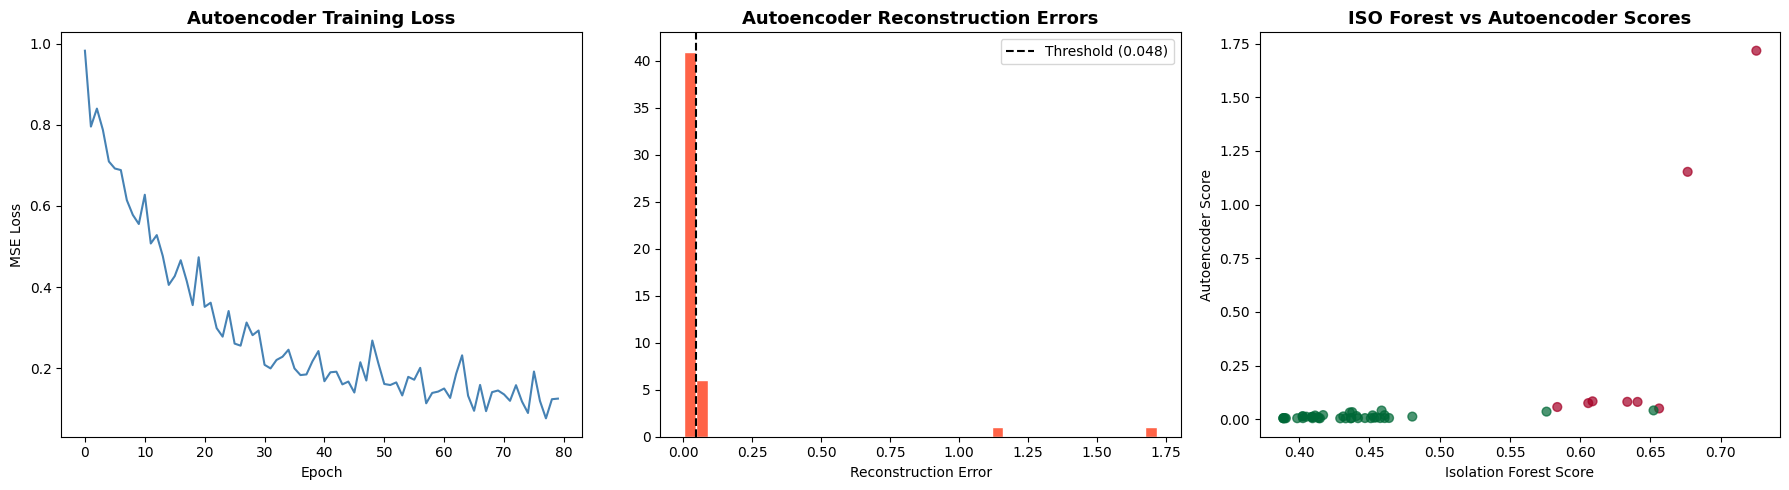

In [29]:
# ─── 7D. Anomaly score plots ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(ae_losses, color="steelblue")
axes[0].set_title("Autoencoder Training Loss", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE Loss")

axes[1].hist(ae_scores, bins=40, color="tomato", edgecolor="white")
axes[1].axvline(ae_threshold, color="black", ls="--", label=f"Threshold ({ae_threshold:.3f})")
axes[1].set_title("Autoencoder Reconstruction Errors", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Reconstruction Error")
axes[1].legend()

axes[2].scatter(df_users["iso_score"], df_users["ae_score"],
                c=df_users["ae_anomaly"], cmap="RdYlGn_r", alpha=0.7, s=40)
axes[2].set_title("ISO Forest vs Autoencoder Scores", fontsize=13, fontweight="bold")
axes[2].set_xlabel("Isolation Forest Score")
axes[2].set_ylabel("Autoencoder Score")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "anomaly_detection.png", dpi=150, bbox_inches="tight")
plt.show()


## 📊 Stage 8 — CIB Score
Custom coordination metric combining semantic, network, and behavioral signals.

```
CIB_SCORE = 0.35 * semantic_similarity
           + 0.25 * network_density
           + 0.20 * synchronization_score
           + 0.10 * hashtag_overlap
           + 0.10 * url_overlap
```


In [30]:
# ─── 8A. Community-level CIB Score ───────────────────────────────────────────
mm = MinMaxScaler()

def compute_cib_score(row):
    """Compute CIB_SCORE for a community row."""
    semantic_similarity  = float(row.get("avg_self_sim", 0))
    network_density      = float(row.get("density", 0))
    synchronization_score = float(row.get("avg_sync_score", 0))
    hashtag_overlap      = float(row.get("avg_burst_ratio", 0))   # proxy
    url_overlap          = float(row.get("avg_repetition", 0))

    cib = (0.35 * semantic_similarity
         + 0.25 * network_density
         + 0.20 * synchronization_score
         + 0.10 * hashtag_overlap
         + 0.10 * url_overlap)
    return round(cib, 4)

df_communities["CIB_SCORE"] = df_communities.apply(compute_cib_score, axis=1)

# Normalize to [0, 1]
if df_communities["CIB_SCORE"].nunique() > 1:
    df_communities["CIB_SCORE_norm"] = mm.fit_transform(df_communities[["CIB_SCORE"]]).flatten()
else:
    df_communities["CIB_SCORE_norm"] = df_communities["CIB_SCORE"]

# Rank communities
df_communities = df_communities.sort_values("CIB_SCORE_norm", ascending=False).reset_index(drop=True)
df_communities["rank"] = df_communities.index + 1

print("🏆 TOP 10 SUSPICIOUS COMMUNITIES (by CIB_SCORE)")
print(df_communities[["rank","community_id","size","CIB_SCORE_norm",
                        "density","avg_sync_score","avg_self_sim","total_posts"]].head(10).to_string())

df_communities.to_csv(OUTPUT_DIR / "community_cib_scores.csv", index=False)
print("\n💾 Saved community_cib_scores.csv")


🏆 TOP 10 SUSPICIOUS COMMUNITIES (by CIB_SCORE)
   rank  community_id  size  CIB_SCORE_norm   density  avg_sync_score  avg_self_sim  total_posts
0     1             1    29             1.0  0.995074        0.862069      0.814411          154
1     2             0    20             0.0  1.000000        0.129289      0.111285           24

💾 Saved community_cib_scores.csv


In [31]:
# ─── 8B. User-level CIB Score ─────────────────────────────────────────────────
# Aggregate: each user gets the CIB score of their community + individual anomaly signals
comm_cib = dict(zip(df_communities["community_id"], df_communities["CIB_SCORE_norm"]))

df_users["community_cib"] = df_users["community"].map(comm_cib).fillna(0)

# Individual CIB score: blend community score with personal anomaly scores
if df_users["ae_score"].max() > 0:
    ae_norm = df_users["ae_score"] / df_users["ae_score"].max()
else:
    ae_norm = df_users["ae_score"]
if df_users["iso_score"].max() > 0:
    iso_norm = df_users["iso_score"] / df_users["iso_score"].max()
else:
    iso_norm = df_users["iso_score"]

df_users["user_CIB_SCORE"] = (0.5 * df_users["community_cib"]
                              + 0.3 * ae_norm
                              + 0.2 * iso_norm).round(4)

df_users_ranked = df_users.sort_values("user_CIB_SCORE", ascending=False)
print("🏆 TOP 20 SUSPICIOUS USERS (by user_CIB_SCORE)")
print(df_users_ranked[["user_id","user_CIB_SCORE","community","post_count",
                         "sync_score","repetition_score","ae_anomaly"]].head(20).to_string())

df_users.to_csv(OUTPUT_DIR / "user_cib_scores.csv", index=False)
print("\n💾 Saved user_cib_scores.csv")


🏆 TOP 20 SUSPICIOUS USERS (by user_CIB_SCORE)
       user_id  user_CIB_SCORE  community  post_count  sync_score  repetition_score  ae_anomaly
48     user_72          0.6908          1           1         0.0               0.0           1
47     user_52          0.6888          1           1         0.0               0.0           1
33  eu_user_20          0.6824          1           6         1.0               0.0           1
46     user_21          0.6801          1           1         0.0               0.0           1
45     user_15          0.6708          1           1         0.0               0.0           1
31  eu_user_19          0.6650          1           6         1.0               0.0           0
43   eu_user_8          0.6346          1           6         1.0               0.0           0
35  eu_user_22          0.6289          1           6         1.0               0.0           0
29  eu_user_17          0.6280          1           6         1.0               0.0       

## 🔍 Stage 9 — Explainability
Generate human-readable reports for each suspicious community.


In [32]:
# ─── 9A. Community explainability report ─────────────────────────────────────
from collections import Counter

def get_community_posts(comm_id, df_clean, df_users):
    """Get all posts from a community."""
    user_list = df_users[df_users["community"] == comm_id]["user_id"].tolist()
    return df_clean[df_clean["user_id"].isin(user_list)]

def extract_top_phrases(texts, n=10, min_len=3):
    """Extract most repeated n-grams from texts."""
    words = " ".join(texts).lower().split()
    bigrams = [f"{words[i]} {words[i+1]}" for i in range(len(words)-1)]
    trigrams = [f"{words[i]} {words[i+1]} {words[i+2]}" for i in range(len(words)-2)]
    counter = Counter(bigrams + trigrams)
    # Filter short/noisy
    filtered = {k: v for k, v in counter.items()
                if len(k) >= min_len and v > 1}
    return Counter(filtered).most_common(n)

def generate_community_report(comm_id, df_communities, df_users, df_clean):
    """Generate a human-readable explainability report for a community."""
    comm_row = df_communities[df_communities["community_id"] == comm_id].iloc[0]
    posts = get_community_posts(comm_id, df_clean, df_users)
    members = df_users[df_users["community"] == comm_id]

    # Top hashtags
    all_tags = []
    for h in posts["hashtags"]:
        try: all_tags.extend(eval(h))
        except: pass
    top_tags = Counter(all_tags).most_common(10)

    # Top URLs
    all_urls = []
    for u in posts["urls"]:
        try: all_urls.extend(eval(u))
        except: pass
    top_urls = Counter(all_urls).most_common(5)

    # Top phrases
    top_phrases = extract_top_phrases(posts["text_clean"].fillna("").tolist())

    report = {
        "community_id": comm_id,
        "rank": int(comm_row.get("rank", 0)),
        "CIB_SCORE": float(comm_row["CIB_SCORE_norm"]),
        "size": int(comm_row["size"]),
        "total_posts": int(comm_row["total_posts"]),
        "graph_density": float(comm_row["density"]),
        "avg_sync_score": float(comm_row["avg_sync_score"]),
        "avg_self_similarity": float(comm_row["avg_self_sim"]),
        "languages": comm_row.get("languages", {}),
        "top_hashtags": top_tags,
        "top_phrases": top_phrases,
        "top_urls": top_urls[:3],
        "coordination_indicators": [],
    }

    # Coordination indicators
    if comm_row["avg_sync_score"] > 0.7:
        report["coordination_indicators"].append("🚨 HIGH temporal synchronization — posts cluster in tight time windows")
    if comm_row["avg_self_sim"] > 0.7:
        report["coordination_indicators"].append("🚨 HIGH semantic similarity — users share near-identical messages")
    if comm_row["density"] > 0.5:
        report["coordination_indicators"].append("🚨 HIGH network density — dense sub-network detected")
    if comm_row["avg_repetition"] > 0.5:
        report["coordination_indicators"].append("⚠️  HIGH content repetition — users repost same content")
    if comm_row["avg_burst_ratio"] > 0.3:
        report["coordination_indicators"].append("⚠️  HIGH burst ratio — rapid-fire posting detected")
    if not report["coordination_indicators"]:
        report["coordination_indicators"].append("ℹ️  Moderate coordination signals — monitor for escalation")

    return report

def print_report(report):
    print(f"\n{'═'*60}")
    print(f"  📋 COMMUNITY REPORT #{report['rank']}  (ID: {report['community_id']})")
    print(f"{'═'*60}")
    print(f"  🎯 CIB Score:          {report['CIB_SCORE']:.4f}")
    print(f"  👥 Community Size:     {report['size']} users")
    print(f"  📝 Total Posts:        {report['total_posts']}")
    print(f"  🕸️  Graph Density:      {report['graph_density']:.4f}")
    print(f"  ⏱️  Avg Sync Score:     {report['avg_sync_score']:.4f}")
    print(f"  🔤 Avg Self-Similarity:{report['avg_self_similarity']:.4f}")
    print(f"\n  🏷️  Top Hashtags:")
    for tag, cnt in report["top_hashtags"][:5]:
        print(f"     {tag:<30} x{cnt}")
    print(f"\n  💬 Top Repeated Phrases:")
    for phrase, cnt in report["top_phrases"][:5]:
        print(f"     '{phrase}'  x{cnt}")
    print(f"\n  🔗 Top URLs:")
    for url, cnt in report["top_urls"]:
        print(f"     {url[:55]}  x{cnt}")
    print(f"\n  ⚠️  Coordination Indicators:")
    for ind in report["coordination_indicators"]:
        print(f"     {ind}")
    print(f"{'─'*60}")

# Generate reports for top 5 communities
top_comm_ids = df_communities.head(5)["community_id"].tolist()
all_reports = []
for cid in top_comm_ids:
    r = generate_community_report(cid, df_communities, df_users, df_clean)
    all_reports.append(r)
    print_report(r)

# Save reports as JSON
with open(OUTPUT_DIR / "community_reports.json", "w") as f:
    json.dump(all_reports, f, indent=2, default=str)
print("\n💾 Saved community_reports.json")



════════════════════════════════════════════════════════════
  📋 COMMUNITY REPORT #1  (ID: 1)
════════════════════════════════════════════════════════════
  🎯 CIB Score:          1.0000
  👥 Community Size:     29 users
  📝 Total Posts:        154
  🕸️  Graph Density:      0.9951
  ⏱️  Avg Sync Score:     0.8621
  🔤 Avg Self-Similarity:0.8144

  🏷️  Top Hashtags:
     #resist                        x1
     #election                      x1
     #democracy                     x1
     #vote                          x1

  💬 Top Repeated Phrases:
     'parlamento europeo'  x52
     'el parlamento'  x28
     'europeo adoptó'  x28
     'adoptó nuevas'  x28
     'nuevas normas'  x28

  🔗 Top URLs:
     https://t.co/cfcd20  x1
     https://t.co/c4ca42  x1
     https://t.co/c81e72  x1

  ⚠️  Coordination Indicators:
     🚨 HIGH temporal synchronization — posts cluster in tight time windows
     🚨 HIGH semantic similarity — users share near-identical messages
     🚨 HIGH network density — dense 

## 📏 Stage 10 — Proxy Evaluation (No Labels Required)
Evaluate cluster quality using structural and stability metrics.


In [33]:
# ─── 10A. Cluster purity & coherence ──────────────────────────────────────────
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

print("📊 PROXY EVALUATION METRICS")
print(f"{'─'*50}")

# 1. Silhouette score (community assignments)
labels = df_users["community"].values
valid = labels != -1
if valid.sum() > 1 and len(set(labels[valid])) > 1:
    sil = silhouette_score(X_scaled[valid], labels[valid], sample_size=min(500, valid.sum()))
    db = davies_bouldin_score(X_scaled[valid], labels[valid])
    ch = calinski_harabasz_score(X_scaled[valid], labels[valid])
    print(f"  Silhouette Score (↑ better, -1..1): {sil:.4f}")
    print(f"  Davies-Bouldin  (↓ better):          {db:.4f}")
    print(f"  Calinski-Harabasz (↑ better):        {ch:.2f}")
else:
    sil = db = ch = 0
    print("  ⚠️  Not enough communities for silhouette evaluation")

# 2. Graph modularity
print(f"\n  Louvain Modularity (↑ better, 0..1):  {modularity:.4f}")

# 3. Community coherence
avg_intra_sim = df_communities["avg_self_sim"].mean()
avg_density = df_communities["density"].mean()
print(f"  Avg Intra-community Similarity:       {avg_intra_sim:.4f}")
print(f"  Avg Community Density:                 {avg_density:.4f}")

# 4. CIB score variance (higher variance = better discrimination)
cib_var = df_communities["CIB_SCORE_norm"].var()
print(f"  CIB Score Variance (↑ better):        {cib_var:.4f}")
print(f"{'─'*50}")


📊 PROXY EVALUATION METRICS
──────────────────────────────────────────────────
  Silhouette Score (↑ better, -1..1): 0.5943
  Davies-Bouldin  (↓ better):          0.8585
  Calinski-Harabasz (↑ better):        27.63

  Louvain Modularity (↑ better, 0..1):  0.2618
  Avg Intra-community Similarity:       0.4628
  Avg Community Density:                 0.9975
  CIB Score Variance (↑ better):        0.5000
──────────────────────────────────────────────────


In [34]:
# ─── 10B. Stability under perturbation ────────────────────────────────────────
print("🔀 Stability analysis — testing under feature perturbation...")

n_trials = 5
stability_scores = []

for trial in range(n_trials):
    # Add 5% Gaussian noise to features
    noise = np.random.normal(0, 0.05, X_scaled.shape)
    X_perturbed = X_scaled + noise

    # Re-run Isolation Forest
    iso_trial = IsolationForest(n_estimators=100, contamination=0.15,
                                 random_state=trial, n_jobs=-1)
    pred_trial = iso_trial.fit_predict(X_perturbed)
    scores_trial = -iso_trial.score_samples(X_perturbed)

    # Correlation with original scores
    corr = np.corrcoef(iso_anomaly_score, scores_trial)[0, 1]
    stability_scores.append(corr)

avg_stability = np.mean(stability_scores)
print(f"  Score correlation across {n_trials} perturbation trials:")
for i, s in enumerate(stability_scores):
    print(f"    Trial {i+1}: r = {s:.4f}")
print(f"  ✅ Average stability: {avg_stability:.4f} (1.0 = perfectly stable)")


🔀 Stability analysis — testing under feature perturbation...
  Score correlation across 5 perturbation trials:
    Trial 1: r = 0.8186
    Trial 2: r = 0.8748
    Trial 3: r = 0.8717
    Trial 4: r = 0.8083
    Trial 5: r = 0.8236
  ✅ Average stability: 0.8394 (1.0 = perfectly stable)


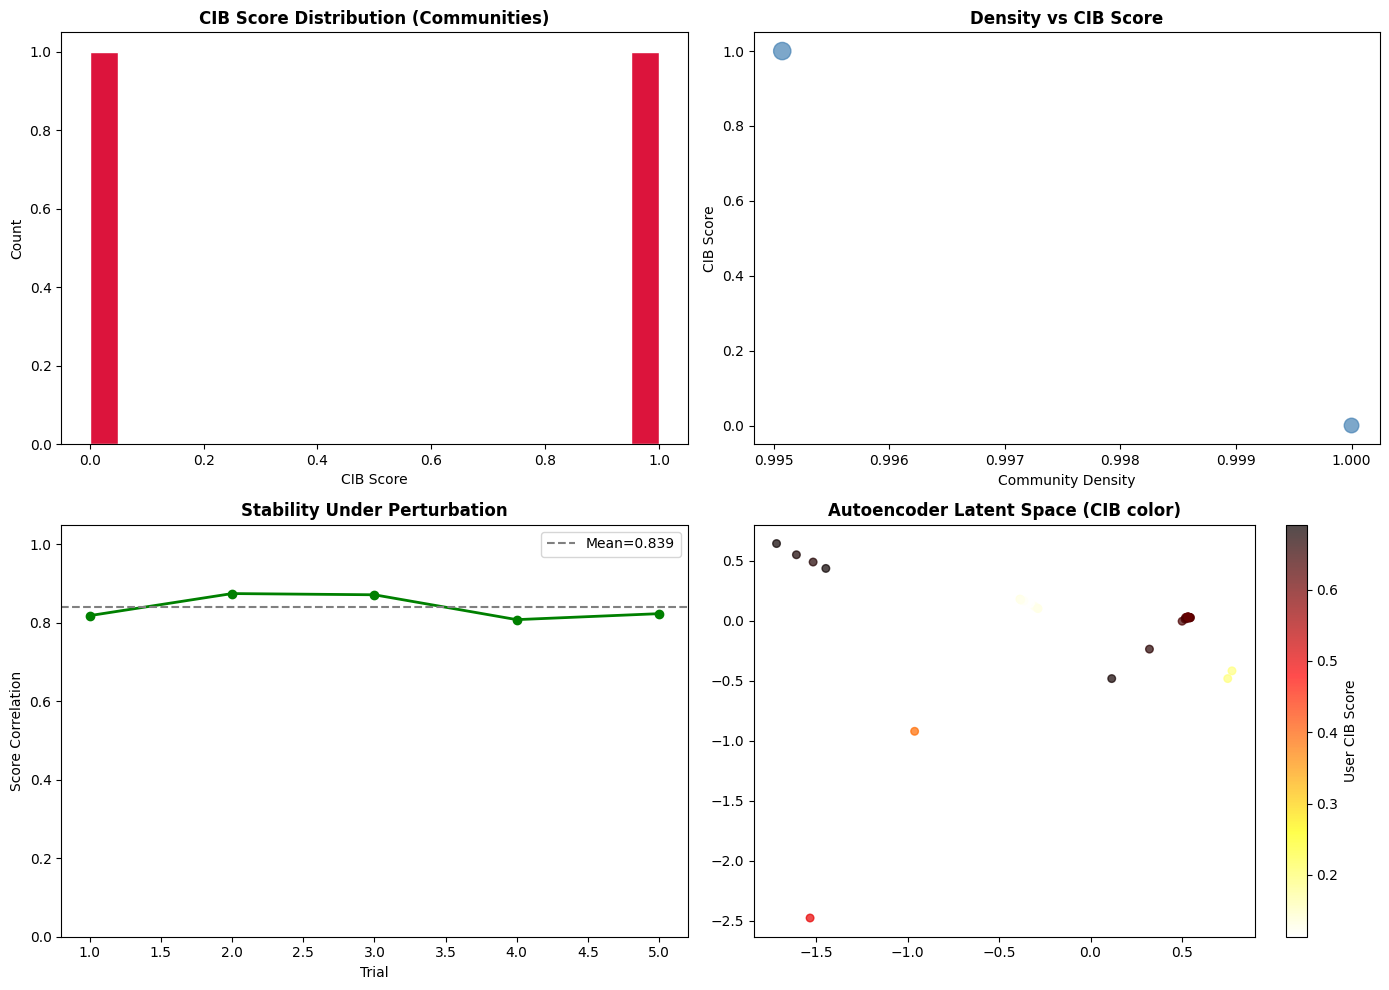

In [35]:
# ─── 10C. Evaluation dashboard plot ──────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# CIB score distribution
axes[0,0].hist(df_communities["CIB_SCORE_norm"], bins=20,
               color="crimson", edgecolor="white")
axes[0,0].set_title("CIB Score Distribution (Communities)", fontsize=12, fontweight="bold")
axes[0,0].set_xlabel("CIB Score")
axes[0,0].set_ylabel("Count")

# Community density vs CIB score
axes[0,1].scatter(df_communities["density"], df_communities["CIB_SCORE_norm"],
                  s=df_communities["size"]*5+10, alpha=0.7, color="steelblue")
axes[0,1].set_title("Density vs CIB Score", fontsize=12, fontweight="bold")
axes[0,1].set_xlabel("Community Density")
axes[0,1].set_ylabel("CIB Score")

# Stability plot
axes[1,0].plot(range(1, n_trials+1), stability_scores, "o-", color="green", linewidth=2)
axes[1,0].axhline(avg_stability, ls="--", color="gray", label=f"Mean={avg_stability:.3f}")
axes[1,0].set_title("Stability Under Perturbation", fontsize=12, fontweight="bold")
axes[1,0].set_xlabel("Trial")
axes[1,0].set_ylabel("Score Correlation")
axes[1,0].legend()
axes[1,0].set_ylim(0, 1.05)

# PCA of latent space with anomaly coloring
pca2 = PCA(n_components=2, random_state=42)
latents_2d = pca2.fit_transform(ae_latents)
sc = axes[1,1].scatter(latents_2d[:, 0], latents_2d[:, 1],
                        c=df_users["user_CIB_SCORE"].values,
                        cmap="hot_r", s=30, alpha=0.7)
axes[1,1].set_title("Autoencoder Latent Space (CIB color)", fontsize=12, fontweight="bold")
plt.colorbar(sc, ax=axes[1,1], label="User CIB Score")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "evaluation_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()


## 🖥️ Stage 11 — Streamlit Dashboard
Full Streamlit application code. Run with `streamlit run cib_dashboard.py` or via `localtunnel` in Colab.


In [36]:
# ─── 11A. Write Streamlit app to file ────────────────────────────────────────
STREAMLIT_CODE = '''
import streamlit as st
import pandas as pd
import numpy as np
import json
import plotly.express as px
import plotly.graph_objects as go
import networkx as nx
from pathlib import Path

st.set_page_config(
    page_title="CIB Detection Dashboard",
    page_icon="🌐",
    layout="wide",
    initial_sidebar_state="expanded"
)

DATA_DIR = Path("processed_data")

@st.cache_data
def load_data():
    df_clean = pd.read_csv(DATA_DIR / "merged_dataset.csv")
    df_users = pd.read_csv(DATA_DIR / "user_cib_scores.csv")
    df_communities = pd.read_csv(DATA_DIR / "community_cib_scores.csv")
    with open(DATA_DIR / "community_reports.json") as f:
        reports = json.load(f)
    return df_clean, df_users, df_communities, reports

try:
    df_clean, df_users, df_communities, reports = load_data()
    data_loaded = True
except Exception as e:
    st.error(f"Data not found: {e}. Please run the notebook first.")
    data_loaded = False

st.title("🌐 CIB Detection Dashboard")
st.markdown("**Coordinated Inauthentic Behavior** detection across multilingual social media.")

if data_loaded:
    # ── KPI row ──────────────────────────────────────────────────
    col1, col2, col3, col4, col5 = st.columns(5)
    col1.metric("Total Posts",    f"{len(df_clean):,}")
    col2.metric("Unique Users",   f"{df_users['user_id'].nunique():,}")
    col3.metric("Communities",    f"{df_communities['community_id'].nunique():,}")
    col4.metric("Suspicious (High CIB)", f"{(df_communities['CIB_SCORE_norm'] > 0.5).sum():,}")
    col5.metric("Languages",      f"{df_clean['language'].nunique():,}")

    st.markdown("---")

    # ── Tabs ─────────────────────────────────────────────────────
    tab1, tab2, tab3, tab4, tab5 = st.tabs([
        "📊 CIB Scores", "🕸️ Community Graph",
        "📅 Timeline", "🌍 Languages", "#️⃣ Hashtags"
    ])

    with tab1:
        st.subheader("Suspicious Communities — Ranked by CIB Score")
        fig = px.bar(
            df_communities.head(20),
            x="community_id", y="CIB_SCORE_norm",
            color="CIB_SCORE_norm", color_continuous_scale="Reds",
            labels={"CIB_SCORE_norm": "CIB Score", "community_id": "Community"},
            hover_data=["size","density","avg_sync_score","total_posts"],
            title="Top 20 Communities by CIB Score"
        )
        st.plotly_chart(fig, use_container_width=True)

        st.subheader("Community Detail Table")
        st.dataframe(
            df_communities[["rank","community_id","size","CIB_SCORE_norm",
                            "density","avg_sync_score","avg_self_sim","total_posts"]]
            .style.background_gradient(subset=["CIB_SCORE_norm"], cmap="Reds"),
            use_container_width=True
        )

        st.subheader("Community Reports")
        for r in reports[:3]:
            with st.expander(f"Community #{r.get('rank',0)} — CIB Score: {r['CIB_SCORE']:.3f}"):
                c1, c2 = st.columns(2)
                c1.metric("Size", r["size"])
                c1.metric("Total Posts", r["total_posts"])
                c2.metric("Density", f"{r['graph_density']:.3f}")
                c2.metric("Sync Score", f"{r['avg_sync_score']:.3f}")
                st.write("**⚠️ Coordination Indicators:**")
                for ind in r["coordination_indicators"]:
                    st.write(f"- {ind}")
                if r["top_hashtags"]:
                    st.write("**Top Hashtags:**",
                             " | ".join([f"`{t[0]}`×{t[1]}" for t in r["top_hashtags"][:5]]))

    with tab2:
        st.subheader("Community Graph (Network Structure)")
        st.info("Full interactive graph requires PyVis. Showing community summary.")
        fig2 = px.scatter(
            df_communities,
            x="density", y="avg_sync_score",
            size="size", color="CIB_SCORE_norm",
            color_continuous_scale="hot_r",
            hover_data=["community_id","size","total_posts"],
            labels={"density": "Graph Density", "avg_sync_score": "Avg Sync Score"},
            title="Community Space: Density vs Synchronization"
        )
        st.plotly_chart(fig2, use_container_width=True)

    with tab3:
        st.subheader("Post Timeline Analysis")
        if "timestamp" in df_clean.columns:
            df_clean["ts"] = pd.to_datetime(df_clean["timestamp"], utc=True, errors="coerce")
            df_timeline = df_clean.dropna(subset=["ts"]).copy()
            df_timeline["hour"] = df_timeline["ts"].dt.floor("H")
            counts = df_timeline.groupby(["hour","source"]).size().reset_index(name="count")
            fig3 = px.line(counts, x="hour", y="count", color="source",
                          title="Post Volume Over Time by Source")
            st.plotly_chart(fig3, use_container_width=True)
        else:
            st.warning("No timestamp data available.")

    with tab4:
        st.subheader("Language Distribution")
        lang_counts = df_clean["language"].value_counts().reset_index()
        lang_counts.columns = ["language","count"]
        fig4 = px.pie(lang_counts.head(12), names="language", values="count",
                     title="Language Distribution Across All Posts",
                     color_discrete_sequence=px.colors.qualitative.Set3)
        st.plotly_chart(fig4, use_container_width=True)

        fig5 = px.bar(lang_counts.head(15), x="language", y="count",
                     color="count", color_continuous_scale="Blues",
                     title="Top Languages (Bar Chart)")
        st.plotly_chart(fig5, use_container_width=True)

    with tab5:
        st.subheader("Hashtag Analysis")
        all_tags = []
        for row in df_clean["hashtags"].dropna():
            try:
                tags = eval(row)
                if isinstance(tags, list):
                    all_tags.extend(tags)
            except Exception:
                pass
        from collections import Counter
        tag_counts = pd.DataFrame(Counter(all_tags).most_common(30),
                                  columns=["hashtag","count"])
        fig6 = px.bar(tag_counts, x="count", y="hashtag", orientation="h",
                     color="count", color_continuous_scale="Reds",
                     title="Top 30 Hashtags by Frequency")
        fig6.update_layout(yaxis=dict(autorange="reversed"))
        st.plotly_chart(fig6, use_container_width=True)
'''

with open("/content/cib_dashboard.py", "w") as f:
    f.write(STREAMLIT_CODE)

print("✅ Streamlit dashboard written to /content/cib_dashboard.py")
print("\nTo launch the dashboard in Colab, run the next cell.")


✅ Streamlit dashboard written to /content/cib_dashboard.py

To launch the dashboard in Colab, run the next cell.


In [37]:
# ─── 11B. Launch Streamlit via localtunnel ───────────────────────────────────
# Uncomment and run to start the dashboard

# !pip install -q localtunnel
# import subprocess, threading, time

# def run_streamlit():
#     subprocess.run([
#         "streamlit", "run", "/content/cib_dashboard.py",
#         "--server.port", "8501",
#         "--server.headless", "true",
#         "--server.enableCORS", "false",
#         "--server.enableXsrfProtection", "false",
#     ])

# t = threading.Thread(target=run_streamlit, daemon=True)
# t.start()
# time.sleep(5)

# # Open public tunnel
# !npx --yes localtunnel --port 8501

print("ℹ️  Streamlit launch cell is commented out.")
print("    Uncomment the above code to start the dashboard.")
print("    Make sure to run: pip install localtunnel")


ℹ️  Streamlit launch cell is commented out.
    Uncomment the above code to start the dashboard.
    Make sure to run: pip install localtunnel


## 🧬 Stage 12 — Research-Level GNN Pipeline
Advanced pipeline:
```
Data → XLM-RoBERTa Embeddings → Graph Construction → GraphSAGE → Graph Autoencoder → Anomaly Detection → CIB Score
```
Uses PyTorch Geometric if available.


In [38]:
# ─── 12A. XLM-RoBERTa embeddings ─────────────────────────────────────────────
print("📥 Loading XLM-RoBERTa for Stage 12...")

try:
    from transformers import AutoTokenizer, AutoModel

    XLM_MODEL_NAME = "xlm-roberta-base"
    xlm_tokenizer = AutoTokenizer.from_pretrained(XLM_MODEL_NAME)
    xlm_model = AutoModel.from_pretrained(XLM_MODEL_NAME).to(DEVICE)
    print(f"✅ XLM-RoBERTa loaded on {DEVICE}")
    XLM_AVAILABLE = True
except Exception as e:
    print(f"⚠️  XLM-RoBERTa not available: {e}")
    print("ℹ️  Falling back to paraphrase-multilingual embeddings for Stage 12")
    XLM_AVAILABLE = False


📥 Loading XLM-RoBERTa for Stage 12...


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ XLM-RoBERTa loaded on cuda


In [39]:
# ─── 12B. XLM-RoBERTa mean-pooling embedding ──────────────────────────────────
def mean_pool(token_embeds, attention_mask):
    """Mean pool token embeddings using attention mask."""
    mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeds.size()).float()
    return (token_embeds * mask_expanded).sum(1) / mask_expanded.sum(1).clamp(min=1e-9)

def get_xlm_embeddings(texts, tokenizer, model, batch_size=32, max_len=128):
    """Get normalized XLM-RoBERTa embeddings for a list of texts."""
    all_embeds = []
    model.eval()
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch = texts[i:i+batch_size]
            encoded = tokenizer(batch, padding=True, truncation=True,
                                max_length=max_len, return_tensors="pt")
            encoded = {k: v.to(DEVICE) for k, v in encoded.items()}
            output = model(**encoded)
            pooled = mean_pool(output.last_hidden_state, encoded["attention_mask"])
            pooled = torch.nn.functional.normalize(pooled, dim=-1)
            all_embeds.append(pooled.cpu().numpy())
            if (i // batch_size) % 5 == 0:
                print(f"   Processed {min(i+batch_size, len(texts))}/{len(texts)}")
    return np.vstack(all_embeds)

# Use XLM-RoBERTa if available, else reuse mpnet embeddings
if XLM_AVAILABLE:
    texts_clean = df_clean["text_clean"].fillna("").tolist()
    print(f"🔤 Computing XLM-RoBERTa embeddings for {len(texts_clean)} texts...")
    xlm_cache = get_cache_path("xlm_roberta_main")
    if xlm_cache.exists():
        xlm_embeddings = np.load(xlm_cache)
        print(f"   ⚡ Loaded from cache: {xlm_embeddings.shape}")
    else:
        xlm_embeddings = get_xlm_embeddings(texts_clean, xlm_tokenizer, xlm_model)
        np.save(xlm_cache, xlm_embeddings)
        print(f"   💾 Saved XLM embeddings: {xlm_embeddings.shape}")
else:
    xlm_embeddings = embeddings  # Reuse mpnet embeddings
    print(f"ℹ️  Using mpnet embeddings: {xlm_embeddings.shape}")


🔤 Computing XLM-RoBERTa embeddings for 178 texts...
   Processed 32/178
   Processed 178/178
   💾 Saved XLM embeddings: (178, 768)


In [40]:
# ─── 12C. Build PyG graph ─────────────────────────────────────────────────────
if PYG_AVAILABLE:
    from torch_geometric.data import Data
    import torch_geometric.utils as pyg_utils

    print("🕸️  Building PyTorch Geometric graph...")

    # User-level embeddings (same as before)
    user_xlm_embeds = np.stack([
        xlm_embeddings[df_clean[df_clean["user_id"] == uid].index].mean(axis=0)
        if len(df_clean[df_clean["user_id"] == uid]) > 0
        else np.zeros(xlm_embeddings.shape[1])
        for uid in df_users["user_id"]
    ])

    # Node features: concat XLM embed + handcrafted features
    feature_cols_gnn = [
        "post_count","avg_self_sim","sync_score","repetition_score",
        "burst_ratio","degree_centrality","clustering_coeff"
    ]
    X_hand = df_users[feature_cols_gnn].fillna(0).values
    X_hand_scaled = StandardScaler().fit_transform(X_hand)

    # Concatenate: [XLM_embed | hand_features]
    node_features = np.hstack([user_xlm_embeds, X_hand_scaled])
    x = torch.FloatTensor(node_features)

    # Build edge list from coordination graph G
    user_id_to_idx = {uid: idx for idx, uid in enumerate(df_users["user_id"])}
    edges_src, edges_dst, edge_attrs = [], [], []

    for u, v, data in G.edges(data=True):
        if u in user_id_to_idx and v in user_id_to_idx:
            i_idx = user_id_to_idx[u]
            j_idx = user_id_to_idx[v]
            edges_src += [i_idx, j_idx]
            edges_dst += [j_idx, i_idx]
            w = data.get("weight", 0.5)
            edge_attrs += [w, w]

    if edges_src:
        edge_index = torch.LongTensor([edges_src, edges_dst])
        edge_weight = torch.FloatTensor(edge_attrs)
    else:
        # No edges: create dummy self-loops
        edge_index = torch.LongTensor([[i, i] for i in range(len(df_users))]).T
        edge_weight = torch.ones(len(df_users))

    # Labels (proxy: community assignment)
    y = torch.LongTensor(df_users["community"].values)

    pyg_data = Data(x=x, edge_index=edge_index, edge_attr=edge_weight, y=y)
    pyg_data = pyg_data.to(DEVICE)

    print(f"✅ PyG Data object:")
    print(f"   Nodes:          {pyg_data.num_nodes}")
    print(f"   Edges:          {pyg_data.num_edges}")
    print(f"   Node features:  {pyg_data.num_node_features}")
else:
    print("⚠️  PyTorch Geometric not available — skipping graph object creation.")
    print("ℹ️  Node features will use numpy arrays instead.")
    pyg_data = None


🕸️  Building PyTorch Geometric graph...
✅ PyG Data object:
   Nodes:          49
   Edges:          2204
   Node features:  775


In [41]:
# ─── 12D. GraphSAGE encoder ───────────────────────────────────────────────────
if PYG_AVAILABLE:
    from torch_geometric.nn import SAGEConv
    import torch.nn.functional as F

    class GraphSAGEEncoder(nn.Module):
        """GraphSAGE encoder producing node embeddings."""
        def __init__(self, in_dim, hidden_dim=128, out_dim=64, dropout=0.3):
            super().__init__()
            self.conv1 = SAGEConv(in_dim, hidden_dim, aggr="mean")
            self.conv2 = SAGEConv(hidden_dim, out_dim, aggr="mean")
            self.bn1 = nn.BatchNorm1d(hidden_dim)
            self.dropout = nn.Dropout(dropout)

        def forward(self, x, edge_index):
            x = self.conv1(x, edge_index)
            x = self.bn1(x)
            x = F.relu(x)
            x = self.dropout(x)
            x = self.conv2(x, edge_index)
            return F.normalize(x, dim=-1)

    class GraphAutoencoder(nn.Module):
        """Graph Autoencoder: GraphSAGE encoder + MLP decoder."""
        def __init__(self, in_dim, hidden_dim=128, latent_dim=32, dropout=0.3):
            super().__init__()
            self.encoder = GraphSAGEEncoder(in_dim, hidden_dim, latent_dim, dropout)
            self.decoder = nn.Sequential(
                nn.Linear(latent_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, in_dim),
            )

        def forward(self, x, edge_index):
            z = self.encoder(x, edge_index)
            x_recon = self.decoder(z)
            return x_recon, z

    in_dim = pyg_data.num_node_features
    gae_model = GraphAutoencoder(in_dim=in_dim, hidden_dim=128, latent_dim=32).to(DEVICE)
    print(f"✅ GraphAutoencoder instantiated")
    print(f"   Input dim:  {in_dim}")
    print(f"   Parameters: {sum(p.numel() for p in gae_model.parameters()):,}")

else:
    # Fallback: standard MLP autoencoder for GNN-free pipeline
    in_dim = node_features_fallback_dim = X_scaled.shape[1]
    gae_model = AnomalyAutoencoder(in_dim, latent_dim=32).to(DEVICE)
    print(f"⚠️  Using MLP Autoencoder fallback (no PyG). Input dim: {in_dim}")


✅ GraphAutoencoder instantiated
   Input dim:  775
   Parameters: 311,207


In [42]:
# ─── 12E. Train Graph Autoencoder ────────────────────────────────────────────
def train_gae(model, data, epochs=100, lr=1e-3, use_pyg=True):
    """Train the Graph Autoencoder."""
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    criterion = nn.MSELoss()
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    losses = []
    model.train()

    for epoch in range(epochs):
        optimizer.zero_grad()

        if use_pyg and isinstance(data, Data):
            recon, z = model(data.x, data.edge_index)
            loss = criterion(recon, data.x)
        else:
            x_t = torch.FloatTensor(X_scaled).to(DEVICE)
            recon, z = model(x_t)
            loss = criterion(recon, x_t)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        losses.append(loss.item())

        if (epoch + 1) % 20 == 0:
            print(f"   Epoch {epoch+1:>3}/{epochs}  Loss: {losses[-1]:.6f}  "
                  f"LR: {scheduler.get_last_lr()[0]:.6f}")

    return losses

print(f"🧠 Training Graph Autoencoder on {DEVICE}...")
use_pyg = PYG_AVAILABLE and pyg_data is not None
gae_losses = train_gae(gae_model, pyg_data if use_pyg else None,
                       epochs=100, lr=5e-4, use_pyg=use_pyg)

torch.save(gae_model.state_dict(), OUTPUT_DIR / "graph_autoencoder.pt")
print("💾 Graph Autoencoder saved.")


🧠 Training Graph Autoencoder on cuda...
   Epoch  20/100  Loss: 0.007662  LR: 0.000452
   Epoch  40/100  Loss: 0.005844  LR: 0.000327
   Epoch  60/100  Loss: 0.004581  LR: 0.000173
   Epoch  80/100  Loss: 0.004037  LR: 0.000048
   Epoch 100/100  Loss: 0.003962  LR: 0.000000
💾 Graph Autoencoder saved.


In [43]:
# ─── 12F. GNN anomaly detection & CIB scoring ────────────────────────────────
print("📊 Computing GNN-based anomaly scores...")

gae_model.eval()
with torch.no_grad():
    if use_pyg and pyg_data is not None:
        recon_gae, z_gae = gae_model(pyg_data.x, pyg_data.edge_index)
        gae_recon_err = ((pyg_data.x - recon_gae) ** 2).mean(dim=1).cpu().numpy()
        z_gae_np = z_gae.cpu().numpy()
    else:
        x_t = torch.FloatTensor(X_scaled).to(DEVICE)
        recon_gae, z_gae = gae_model(x_t)
        gae_recon_err = ((x_t - recon_gae) ** 2).mean(dim=1).cpu().numpy()
        z_gae_np = z_gae.cpu().numpy()

# Normalize
gae_norm = gae_recon_err / (gae_recon_err.max() + 1e-9)
df_users["gae_score"] = gae_norm

# Final CIB Score (incorporating GNN)
df_users["CIB_SCORE_GNN"] = (
    0.40 * df_users["community_cib"] +
    0.25 * gae_norm +
    0.20 * (ae_norm if isinstance(ae_norm, np.ndarray) else ae_norm.values) +
    0.15 * iso_norm
).round(4)

df_users_gnn_ranked = df_users.sort_values("CIB_SCORE_GNN", ascending=False)
print("\n🏆 TOP 20 USERS — GNN-Enhanced CIB Score")
print(df_users_gnn_ranked[["user_id","CIB_SCORE_GNN","community","post_count",
                             "sync_score","gae_score"]].head(20).to_string())

df_users.to_csv(OUTPUT_DIR / "user_cib_scores_gnn.csv", index=False)
print("\n💾 Saved user_cib_scores_gnn.csv")


📊 Computing GNN-based anomaly scores...

🏆 TOP 20 USERS — GNN-Enhanced CIB Score
       user_id  CIB_SCORE_GNN  community  post_count  sync_score  gae_score
47     user_52         0.7904          1           1         0.0   1.000000
46     user_21         0.7266          1           1         0.0   0.770596
45     user_15         0.7001          1           1         0.0   0.691161
48     user_72         0.6986          1           1         0.0   0.626953
33  eu_user_20         0.5689          1           6         1.0   0.133305
31  eu_user_19         0.5575          1           6         1.0   0.136918
43   eu_user_8         0.5344          1           6         1.0   0.134646
35  eu_user_22         0.5311          1           6         1.0   0.138109
25  eu_user_13         0.5305          1           6         1.0   0.140990
20   eu_user_0         0.5294          1           6         1.0   0.142308
29  eu_user_17         0.5292          1           6         1.0   0.133334
32   eu

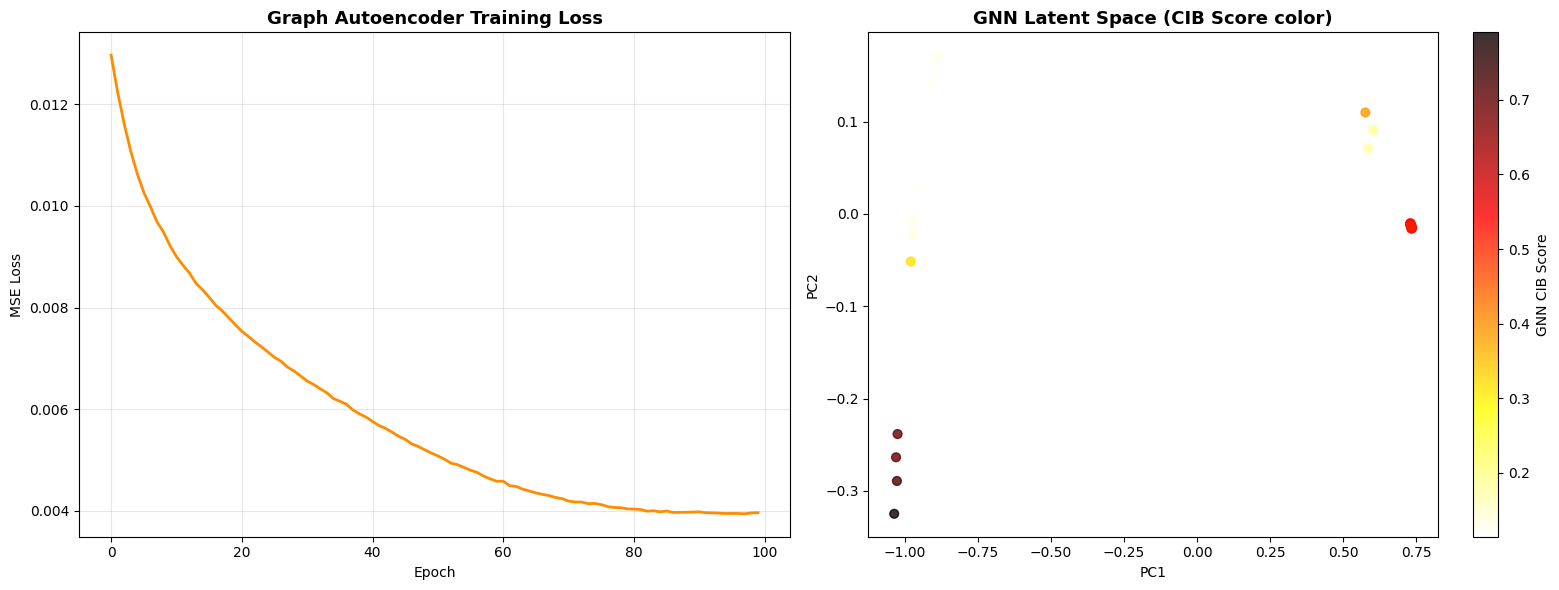

In [44]:
# ─── 12G. GNN latent space visualization ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Training curve
axes[0].plot(gae_losses, color="darkorange", linewidth=2)
axes[0].set_title("Graph Autoencoder Training Loss", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE Loss")
axes[0].grid(True, alpha=0.3)

# GNN latent space with CIB coloring
pca3 = PCA(n_components=2, random_state=42)
z_2d = pca3.fit_transform(z_gae_np)
sc2 = axes[1].scatter(z_2d[:, 0], z_2d[:, 1],
                      c=df_users["CIB_SCORE_GNN"].values,
                      cmap="hot_r", s=40, alpha=0.8)
axes[1].set_title("GNN Latent Space (CIB Score color)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
plt.colorbar(sc2, ax=axes[1], label="GNN CIB Score")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "gnn_analysis.png", dpi=150, bbox_inches="tight")
plt.show()


## ✅ Final Summary & Output Files
All pipeline outputs are saved in `/content/processed_data/`.


In [45]:
# ─── Final summary ────────────────────────────────────────────────────────────
import os

print("\n" + "═"*60)
print("  🎯 CIB DETECTION PIPELINE — COMPLETE")
print("═"*60)

output_files = sorted(OUTPUT_DIR.glob("*"))
print(f"\n📁 Output files in {OUTPUT_DIR}:")
for f in output_files:
    size_kb = os.path.getsize(f) / 1024
    print(f"   {f.name:<45} {size_kb:>7.1f} KB")

print(f"\n📊 Pipeline Summary:")
print(f"   Total posts processed:      {len(df_clean):,}")
print(f"   Unique users analyzed:      {len(df_users):,}")
print(f"   Communities detected:       {df_communities['community_id'].nunique():,}")
print(f"   Languages covered:          {df_clean['language'].nunique():,}")
print(f"   Louvain modularity:         {modularity:.4f}")

top3 = df_communities.head(3)
print(f"\n🏆 Top 3 Suspicious Communities:")
for _, row in top3.iterrows():
    print(f"   Community {int(row['community_id']):<5} "
          f"CIB={row['CIB_SCORE_norm']:.3f}  "
          f"Size={int(row['size'])}  "
          f"Density={row['density']:.3f}")

print(f"\n📦 Models saved:")
print(f"   Autoencoder:            {OUTPUT_DIR}/autoencoder.pt")
print(f"   Graph Autoencoder:      {OUTPUT_DIR}/graph_autoencoder.pt")
print(f"\n🖥️  Dashboard:")
print(f"   Run: streamlit run /content/cib_dashboard.py")
print(f"{'═'*60}")



════════════════════════════════════════════════════════════
  🎯 CIB DETECTION PIPELINE — COMPLETE
════════════════════════════════════════════════════════════

📁 Output files in /content/processed_data:
   anomaly_detection.png                           116.2 KB
   autoencoder.pt                                   17.3 KB
   community_cib_scores.csv                          0.5 KB
   community_reports.json                            2.7 KB
   community_stats.png                              73.2 KB
   coordination_graph.png                         1216.8 KB
   data_overview.png                                80.3 KB
   embedding_pca.png                                64.5 KB
   evaluation_dashboard.png                        120.1 KB
   gnn_analysis.png                                 87.7 KB
   graph_autoencoder.pt                           1222.8 KB
   merged_dataset.csv                               43.9 KB
   merged_raw.csv                                   98.4 KB
   processed_cr